# Proyecto Sprint 6.  

### Elaborado por: 
M.F/MCR Juan Jose Torres Sastre


### Objetivo del proyecto:   
El objetivo de este proyecto es analizar la base de datos de los ventas de video juegos de la empresa Ice para diferentes plataformas como es Nintendo, Xbox, Wii, Sega, etc y que se han vendido a lo largo de diferentes años conforme a la preferencia de los compradores  en las regiones de Norteamérica, Europa, Japón y otras partes del mundo.   
 
La finalidad del proyecto de estudio es la de establecer  el top o ranking de los video juegos que más ventas hallan tenido a lo largo de estos años identificando los juegos que ya no se venden así como de los que actualmente se venden de manera consistente, identificar el tipo de género de video juego que se vende con  más preferencia por parte de los compradores así como la identificación de algún patrón de compra.  

Para identificar si un juego es significativo se tomará como referencia la media +/- 2 std.   

Finalmente establecer recomendaciónes que la empresa Ice pueda implementar para mejorar sus ventas el proximo año.

Como parte del análisis la empresa Ice a solicitado saber si:

— Las calificaciones promedio de los usuarios **user_score** para las plataformas Xbox One y PC son las mismas.   
— Las calificaciones promedio de los usuarios **user_score** para los géneros de Acción y Deportes son diferentes.   
— Si las clasificaciones de *ESRB* afectan a las ventas en regiones individuales es decir en Norte América , Japón , Europa y otros.   

Dentro de las herramientas de análisis se desarrollarán gráficos visuales y tablas estadísticas con agrupaciones que permitan presentar la información analizada y llegar a conclusiones finales y recomendaciones.

### Ruta del archivo:   
/datasets/games.csv

### Diccionario de datos:   
Descripción de datos

— name (Nombre)

— platform (Plataforma)

— year_of_release (Año de lanzamiento)

— genre (Género) 

—  na_sales (ventas en Norteamérica en millones de dólares estadounidenses) 

— eu_sales (ventas en Europa en millones de dólares estadounidenses) 

— jp_sales (ventas en Japón en millones de dólares estadounidenses) 

— other_sales (ventas en otros países en millones de dólares estadounidenses) 

— critic_score (máximo de 100) 

— user_score (máximo de 10) 

— rating (ESRB): Entertainment Software Rating Board, asgnacion de edad del juego.



## Estrategia de análisis:
Como estrategia de análisis del proyecto se pretende realizar de la siguiente manera:

1.- Aplicación de proceso ETL (Extraction, Transformation and Load), para realizar la Carga del data frame, aplicar la Preparacion, Limpieza y Visualización preliminar de la estructura de los datos que conforma el data frame games, aplicar los métodos para la consulta de las descripciones estadísticas básicas de cada columnas y determinar el tipo de dato requerido. 

En esta sección se  identificaran valores nulos y duplicados explícitos en todo el data frame identificado como  **df_games** y sus duplicados implícitos que posiblemente existan en columnas **name**, **genre** y **platform** que por ser columnas del tipo texto se deba hacer una limpieza preliminar de caracteres de espacios (aplicación de métodos strip) y homologación a minúsculas (método lower) para poder agrupar de manera consistente y sin repeticiones.    

Lo anterior nos permitirá realizar el análisis de la información sin duplicados que sesguen el análisis.

2.- Análisis numérico de la información.
En esta sección se realizará la parte de la estadística descriptiva del conjunto de datos de **df_games** proporcionado por la compañía Ice.   

Se agrupará información usando los metodos groupby o pivot, se crearán variables nuevas que permitan  complementar el data frame original asi como analisis de significancia estadistica, de igual manera elaborar diferentes visualizaciones gráficas que permitan entender el comportamiento de las variables que se analicen o presentes.   

Dentro de las variables nuevas a crear están:   
$$
\text{global\_sales}=\text{(na+eu+jp+other)}
$$
$$\text{media juegos anuales} = \text{juegos,mean()}$$ Si un año tiene muchos más juegos que el promedio → probablemente es significativo.  
$$
\text{popularidad=}\frac{\text{global\_sales}}{\text{num\_games}}
$$

Estás variables considera las regiones de Norteamérica , Japón , Europa y otros y sus diferentes segmentaciones mediante agrupaciones de género y plataformas.   

3.- Soporte de analisis con graficos segmentados.   

4.- Crea un perfil de usuario para cada para cada región (NA, UE, JP) y determinar:
* Las cinco plataformas principales. Describiendo las variaciones en sus cuotas de mercado de una región a otra.   
* Los cinco géneros principales y diferencias.     
* indicar si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

5.- Prueba de Hipotesis y Conclusiones. 


## Informacion complememtaria.  
Diccionario de marcas a emplear en analisis:   
```python
brand_map = {
    # Sony
    "PS": "Sony", "PS2": "Sony", "PS3": "Sony", "PS4": "Sony",
    "PSP": "Sony", "PSV": "Sony",

    # Microsoft
    "XB": "Microsoft", "X360": "Microsoft", "XOne": "Microsoft",

    # Nintendo
    "3DS": "Nintendo", "DS": "Nintendo", "GB": "Nintendo",
    "GBA": "Nintendo", "GC": "Nintendo", "N64": "Nintendo",
    "NES": "Nintendo", "SNES": "Nintendo", "Wii": "Nintendo",
    "WiiU": "Nintendo", "WII": "Nintendo", "Wii": "Nintendo"

    # Sega
    "DC": "Sega", "GEN": "Sega", "GG": "Sega",
    "SAT": "Sega", "SCD": "Sega",

    # Otros
    "2600": "Atari",
    "TG16": "NEC", "PCFX": "NEC",
    "NG": "SNK",
    "WS": "Bandai",
    "3DO": "3DO Company",

    # PC
    "PC": "PC"
}

# 1.-  ETL y Analisis preliminar del df games

In [2]:
# importacion de librerias parq analisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Lectura del archivo
import pandas as pd
df_games=pd.read_csv("/datasets/games.csv")

# Inspeccion del data frame df_games

In [4]:
# identificacion , limpieza y homologacion de nombres de columnas
# Bucle para homologacion in de nombres de columnas
df_games.columns = [col.strip().lower() for col in df_games.columns]
print(df_games.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


# Incorporacion de variables global sales

In [5]:
# Global sales
# 1) Calcular las ventas totales para cada juego y guardarlas en una columna nueva
# Crear columna de ventas globales
df_games["global_sales"] = (
    df_games["na_sales"]
    + df_games["eu_sales"]
    + df_games["jp_sales"]
    + df_games["other_sales"]
)

# Verificar
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


In [6]:
#  Visualizacion de datos
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
 11  global_sales     16715 non-null  float64
dtypes: float64(7), object(5)
memory usage: 1.5+ MB


In [7]:
df_games.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
global_sales          0
dtype: int64

De la seccion anterior se identifica que   'User_Score' se va requerir cambiar el tipo de datos de objeto a tipo numerico y para ello se aplicara una funcion que se desarrollo para efectuar la conversion sin perdida de informacion y que se indica a continuacion, los valores no numericos como TBD se le asigna como Nan.

# year_of_release

In [8]:
# Summary year_of_release
summary_years = (
    df_games["year_of_release"]
    .value_counts()
    .sort_index()
    .reset_index(name="juegos") # Se cambia nombre de valor numerico
)
summary_years = summary_years.rename(columns={
    "index": "año",
   "juegos": "total_juegos"
})
print(summary_years)
print()

print("Total Registros:", summary_years["total_juegos"].sum())
print("Número de años:", len(summary_years))
type(summary_years)

       año  total_juegos
0   1980.0             9
1   1981.0            46
2   1982.0            36
3   1983.0            17
4   1984.0            14
5   1985.0            14
6   1986.0            21
7   1987.0            16
8   1988.0            15
9   1989.0            17
10  1990.0            16
11  1991.0            41
12  1992.0            43
13  1993.0            62
14  1994.0           121
15  1995.0           219
16  1996.0           263
17  1997.0           289
18  1998.0           379
19  1999.0           338
20  2000.0           350
21  2001.0           482
22  2002.0           829
23  2003.0           775
24  2004.0           762
25  2005.0           939
26  2006.0          1006
27  2007.0          1197
28  2008.0          1427
29  2009.0          1426
30  2010.0          1255
31  2011.0          1136
32  2012.0           653
33  2013.0           544
34  2014.0           581
35  2015.0           606
36  2016.0           502

Total Registros: 16446
Número de años: 37


pandas.core.frame.DataFrame

In [9]:
# Elementos nulos year_of_realese
mask_null=df_games["year_of_release"].isna()
year_mask_null=df_games[mask_null]
year_mask_null

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E,5.24
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E,3.50
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+,3.06
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN,3.00
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN,2.53
...,...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.00,0.00,43.0,tbd,E10+,0.01
16405,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T,0.01
16448,Inversion,PC,NaN,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M,0.01
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN,0.01


In [10]:
# Valores nulos en year_of_release
print("Valores nulos",mask_null.sum())

Valores nulos 269


Se observan 269 valores nulos <Nan> en year_of_release, de igual manera existe información en el campo Name, en donde podemos obtener el año de lanzamiento del juego, por lo que haremos esta consulta y actualizaremos la tabla de la columna. years of Release y lo que quede se volvera a verificar el numero de valores nulos remanentes.

# name

In [11]:
# Limpieza y homologacion de contenido en name
# Normalizar texto
df_games["name"]= df_games["name"].astype(str).str.strip().str.lower()

In [12]:
# 2da limpieza de contenido de columna name por duplicados implicitos
df_games["name"]= df_games["name"].str.replace(".", "", regex=False)
df_games["name"]= df_games["name"].str.replace(":", "", regex=False)
df_games["name"]= df_games["name"].str.replace("/", "", regex=False)
df_games["name"]= df_games["name"].str.replace("'", "", regex=False)
df_games["name"]= df_games["name"].str.replace("!", "", regex=False)
df_games["name"]= df_games["name"].str.replace("¡", "", regex=False)
df_games["name"]= df_games["name"].str.replace("007", "", regex=False)
df_games["name"]= df_games["name"].str.replace(",", "", regex=False)
df_games["name"]= df_games["name"].str.replace("-", "", regex=False)
print("total de titulos diferentes:",df_games["name"].nunique())

total de titulos diferentes: 11540


In [13]:
# Verificacion de contenido columna name por duplicados implicitos
df_games["name"].value_counts().sort_index()

 quantum of solace                            6
 racing                                       1
 the world is not enough                      2
 tomorrow never dies                          1
1 vs 100                                      1
                                             ..
zumba fitness core                            2
zumba fitness rush                            1
zumba fitness world party                     2
zwei                                          1
zyuden sentai kyoryuger game de gaburincho    1
Name: name, Length: 11540, dtype: int64

In [14]:
# Filtrar filas con NaN en year_of_release o platform
filas_nan = df_games[
    df_games["platform"].isna() | df_games["year_of_release"].isna()
]

print("Monto de filas nulas",filas_nan["global_sales"].sum())
print("Monto global de ventas",df_games["global_sales"].sum()-filas_nan["global_sales"].sum())
print("porcentaje",filas_nan["global_sales"].sum()/filas_nan["global_sales"].sum()/(df_games["global_sales"].sum()-filas_nan["global_sales"].sum())*100,"%")
print("filas nulos",len(filas_nan))

Monto de filas nulas 98.91999999999999
Monto global de ventas 8816.789999999999
porcentaje 0.011341996350145576 %
filas nulos 269


In [15]:
# Imputacion de year_of_releass 
df_games["anio_en_name"] = (
    df_games["name"]
    .str.extract(r"\b(198\d|199\d|200\d|201[0-6])\b")
    .astype("float")  # para permitir NaN
)

print("Recistros nulos en name",df_games["name"].isna().sum())


Recistros nulos en name 0


# year_of_release imputacion

In [16]:
# Se realizara la imputacion de valores del año en. ase a columna name
serie_ant=df_games["year_of_release"].value_counts()
serie_ant.sum()

16446

In [17]:
mask = df_games["year_of_release"].isna() & df_games["anio_en_name"].notna()

df_games.loc[mask, "year_of_release"] = df_games.loc[mask, "anio_en_name"]

In [18]:
df_games[mask][["name", "anio_en_name", "year_of_release"]]

,name,anio_en_name,year_of_release
183,madden nfl 2004,2004.0,2004.0
377,fifa soccer 2004,2004.0,2004.0
475,wwe smackdown vs raw 2006,2006.0,2006.0
1650,nascar thunder 2003,2003.0,2003.0
2492,mlb slugfest 2003,2003.0,2003.0
2572,pes 2009 pro evolution soccer,2009.0,2009.0
3486,madden nfl 2002,2002.0,2002.0
4775,nfl gameday 2003,2003.0,2003.0
5156,nba live 2003,2003.0,2003.0
5336,tomb raider (2013),2013.0,2013.0


In [19]:
# Filtrar filas con NaN en year_of_release o platform
filas_nan = df_games[
    df_games["platform"].isna() | df_games["year_of_release"].isna()
]

print("Monto de filas nulas",filas_nan["global_sales"].sum())
print("Monto global de ventas",df_games["global_sales"].sum()-filas_nan["global_sales"].sum())
print("porcentaje",filas_nan["global_sales"].sum()/filas_nan["global_sales"].sum()/(df_games["global_sales"].sum()-filas_nan["global_sales"].sum())*100,"%")
print("filas nulos",len(filas_nan))

Monto de filas nulas 81.75
Monto global de ventas 8833.96
porcentaje 0.01131995164116659 %
filas nulos 252


In [20]:
# Se realizara la imputacion de valores del año en. ase a columna name
serie_des=df_games["year_of_release"].value_counts()
serie_des.sum()

16463

In [21]:
diferencia=serie_des-serie_ant
diferencia.sort_index(ascending=True).sum()

17

Despues de aplicar limpieza de caracteres especiales, los nombres de los titulos son muy diversos se alcanza una cantidad de 11540
Se tomo la desicion de eliminar los registros ausentes en columna year_of_release ya que después de llenarlo con información disponible en la columna Name se llenaron solamente doce registros ausentes, el resto se va a eliminar debido a que en monto solo repreeenta menos del 0.01%.

# year_of_release imputacion de 17 registros con año y eliminacion de filas nulas

In [22]:
# Elliminación de datos ausentes en columna Year of releasel
mask=df_games["year_of_release"].isna().sum()
mask
#df_games[mask].sort_values(by="global_sales").head()

252

In [23]:
# Eliminacion de filas con datos nulos en year_of_release
df_games = df_games.dropna(subset=["year_of_release"])

In [24]:
#  verificación de borrado
df_games.isna().sum()

name                   0
platform               0
year_of_release        0
genre                  2
na_sales               0
eu_sales               0
jp_sales               0
other_sales            0
critic_score        8467
user_score          6611
rating              6683
global_sales           0
anio_en_name       15638
dtype: int64

# genre visualizacion de filas vacias y eliminacion

In [25]:
maskgen=df_games["genre"].isna()

In [26]:
df_games[maskgen]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,anio_en_name
659,nan,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN,2.39,NaN
14244,nan,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN,0.03,NaN


# Estos registros se van a eliminar  no aportan valor por ausencia de datos relevantes

In [27]:
df_games = df_games.dropna(subset=["genre"])

In [28]:
df_games["genre"].isna().sum()

0

In [29]:
df_games.isna().sum()

name                   0
platform               0
year_of_release        0
genre                  0
na_sales               0
eu_sales               0
jp_sales               0
other_sales            0
critic_score        8465
user_score          6609
rating              6681
global_sales           0
anio_en_name       15636
dtype: int64

# critic_score

In [30]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16461 entries, 0 to 16714
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16461 non-null  object 
 1   platform         16461 non-null  object 
 2   year_of_release  16461 non-null  float64
 3   genre            16461 non-null  object 
 4   na_sales         16461 non-null  float64
 5   eu_sales         16461 non-null  float64
 6   jp_sales         16461 non-null  float64
 7   other_sales      16461 non-null  float64
 8   critic_score     7996 non-null   float64
 9   user_score       9852 non-null   object 
 10  rating           9780 non-null   object 
 11  global_sales     16461 non-null  float64
 12  anio_en_name     825 non-null    float64
dtypes: float64(8), object(5)
memory usage: 1.8+ MB


In [31]:
print("Valores nulos critic_score",df_games["critic_score"].isna().sum())

Valores nulos critic_score 8465


In [32]:
print("Valores no nulos critic_score",df_games["critic_score"].notna().sum())

Valores no nulos critic_score 7996


# Imputacion de valores critic_score usando mediana

In [33]:
# Imputacion de valores nulos por mediana anual por genero

median_cr_score = df_games.groupby("genre")["critic_score"].transform("median")

df_games["median_cr_score"] = median_cr_score

df_games["critic_score"] = df_games["critic_score"].fillna(median_cr_score)

In [34]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16461 entries, 0 to 16714
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16461 non-null  object 
 1   platform         16461 non-null  object 
 2   year_of_release  16461 non-null  float64
 3   genre            16461 non-null  object 
 4   na_sales         16461 non-null  float64
 5   eu_sales         16461 non-null  float64
 6   jp_sales         16461 non-null  float64
 7   other_sales      16461 non-null  float64
 8   critic_score     16461 non-null  float64
 9   user_score       9852 non-null   object 
 10  rating           9780 non-null   object 
 11  global_sales     16461 non-null  float64
 12  anio_en_name     825 non-null    float64
 13  median_cr_score  16461 non-null  float64
dtypes: float64(9), object(5)
memory usage: 1.9+ MB


In [35]:
df_games[["genre","year_of_release","median_cr_score",
          "critic_score","user_score"]].head()

,genre,year_of_release,median_cr_score,critic_score,user_score
0,Sports,2006.0,75.0,76.0,8
1,Platform,1985.0,69.5,69.5,NaN
2,Racing,2008.0,69.0,82.0,8.3
3,Sports,2009.0,75.0,80.0,8
4,Role-Playing,1996.0,74.0,74.0,NaN


In [36]:
df_games.isna().sum()

name                   0
platform               0
year_of_release        0
genre                  0
na_sales               0
eu_sales               0
jp_sales               0
other_sales            0
critic_score           0
user_score          6609
rating              6681
global_sales           0
anio_en_name       15636
median_cr_score        0
dtype: int64

In [37]:
print("Valores nulos",df_games["critic_score"].isna().sum())

Valores nulos 0


In [38]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16461 entries, 0 to 16714
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16461 non-null  object 
 1   platform         16461 non-null  object 
 2   year_of_release  16461 non-null  float64
 3   genre            16461 non-null  object 
 4   na_sales         16461 non-null  float64
 5   eu_sales         16461 non-null  float64
 6   jp_sales         16461 non-null  float64
 7   other_sales      16461 non-null  float64
 8   critic_score     16461 non-null  float64
 9   user_score       9852 non-null   object 
 10  rating           9780 non-null   object 
 11  global_sales     16461 non-null  float64
 12  anio_en_name     825 non-null    float64
 13  median_cr_score  16461 non-null  float64
dtypes: float64(9), object(5)
memory usage: 1.9+ MB


In [39]:
# Coeficiente de correlacion entre variable critic score y mediana calculada por año.
correl=df_games["critic_score"].corr(df_games["median_cr_score"])
print('correlacion=',round(correl,2))

correlacion= 0.25


### Nota 
Se uso mediana para efectuar la imputacion de valores ausentes, no es la mejor aproximacion dado que su coeficiente de correlacion es de 0,25. No se eliminan registros para no perder informacion de todo el dataframe.    
Se puede realizar analisis de regresion multiple para checar si podemos imputar valores en base al modelo de regresion con un mejor coeficiente de regresion.

In [40]:
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,anio_en_name,median_cr_score
0,wii sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E,82.54,NaN,75.0
1,super mario bros,NES,1985.0,Platform,29.08,3.58,6.81,0.77,69.5,NaN,NaN,40.24,NaN,69.5
2,mario kart wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,NaN,69.0
3,wii sports resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E,32.77,NaN,75.0
4,pokemon redpokemon blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,74.0,NaN,NaN,31.38,NaN,74.0


# user_score

In [41]:
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,anio_en_name,median_cr_score
0,wii sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E,82.54,NaN,75.0
1,super mario bros,NES,1985.0,Platform,29.08,3.58,6.81,0.77,69.5,NaN,NaN,40.24,NaN,69.5
2,mario kart wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,NaN,69.0
3,wii sports resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E,32.77,NaN,75.0
4,pokemon redpokemon blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,74.0,NaN,NaN,31.38,NaN,74.0


In [42]:
df_games = df_games.drop("anio_en_name", axis=1)

df_games.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score          0
user_score         6609
rating             6681
global_sales          0
median_cr_score       0
dtype: int64

In [43]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16461 entries, 0 to 16714
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16461 non-null  object 
 1   platform         16461 non-null  object 
 2   year_of_release  16461 non-null  float64
 3   genre            16461 non-null  object 
 4   na_sales         16461 non-null  float64
 5   eu_sales         16461 non-null  float64
 6   jp_sales         16461 non-null  float64
 7   other_sales      16461 non-null  float64
 8   critic_score     16461 non-null  float64
 9   user_score       9852 non-null   object 
 10  rating           9780 non-null   object 
 11  global_sales     16461 non-null  float64
 12  median_cr_score  16461 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1.8+ MB


In [44]:
# Analisis de columna user_score
import pandas as pd

col = df_games["user_score"]

# Normalizar texto (por si hay "TBD", "tbd", "Tbd", etc.)
col_clean = col.astype(str).str.strip().str.lower()

# Conteo de tbd en cualquier formato
tbd_count = (col_clean == "tbd").sum()

# Conversión numérica
df_games["user_score_num"] = pd.to_numeric(col_clean, errors="coerce")

# Conteos
total = len(col)
no_nulos_original = col.notna().sum()
numericos_final = df_games["user_score_num"].notna().sum()
nan_final = df_games["user_score_num"].isna().sum()

# Resultados
print(f"Total filas: {total}")
print(f"No nulos originales: {no_nulos_original}")
print(f"'tbd' (cualquier formato): {tbd_count}")
print(f"Numéricos finales: {numericos_final}")
print(f"NaN finales: {nan_final}")


Total filas: 16461
No nulos originales: 9852
'tbd' (cualquier formato): 2378
Numéricos finales: 7474
NaN finales: 8987


In [45]:
# Visualizacion user_score
maskscore=df_games["user_score"].isna()
df_games[maskscore].isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score          0
user_score         6609
rating             6547
global_sales          0
median_cr_score       0
user_score_num     6609
dtype: int64

In [46]:
df_games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,median_cr_score,user_score_num
0,wii sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E,82.54,75.0,8.0
1,super mario bros,NES,1985.0,Platform,29.08,3.58,6.81,0.77,69.5,NaN,NaN,40.24,69.5,NaN
2,mario kart wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,69.0,8.3
3,wii sports resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E,32.77,75.0,8.0
4,pokemon redpokemon blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,74.0,NaN,NaN,31.38,74.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16710,samurai warriors sanada maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,68.0,NaN,NaN,0.01,68.0,NaN
16711,lma manager 2,X360,2006.0,Sports,0.00,0.01,0.00,0.00,75.0,NaN,NaN,0.01,75.0,NaN
16712,haitaka no psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,66.0,NaN,NaN,0.01,66.0,NaN
16713,spirits & spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,69.5,NaN,NaN,0.01,69.5,NaN


En user_score exite informacion valiosa por lo cual se realizara una imputacion para rellenar campos vacios y con tbd por la mediana del valor obtenido por año por el tipo de genero que se halla calificado en ese año

Se observan 2378 con tbd y 6609 registros nulos finales. Se imputara valores con la mediana que se obtenga del año y del género correspondiente

# Imputacion user score

In [47]:
# visualización general del data Frame
df_games.notna().sum()

name               16461
platform           16461
year_of_release    16461
genre              16461
na_sales           16461
eu_sales           16461
jp_sales           16461
other_sales        16461
critic_score       16461
user_score          9852
rating              9780
global_sales       16461
median_cr_score    16461
user_score_num      7474
dtype: int64

# imputacion de datos en user_score

In [48]:
df_games["user_score"] = pd.to_numeric(df_games["user_score"], errors="coerce")
mediana_user_score = df_games.groupby("genre")["user_score"].transform("median")

df_games["median_user_score"] = mediana_user_score

df_games["user_score"] = df_games["user_score"].fillna(mediana_user_score)

In [49]:
# visualización del data Frame de cambios
df_games.isna().sum()
df_games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16461 entries, 0 to 16714
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               16461 non-null  object 
 1   platform           16461 non-null  object 
 2   year_of_release    16461 non-null  float64
 3   genre              16461 non-null  object 
 4   na_sales           16461 non-null  float64
 5   eu_sales           16461 non-null  float64
 6   jp_sales           16461 non-null  float64
 7   other_sales        16461 non-null  float64
 8   critic_score       16461 non-null  float64
 9   user_score         16461 non-null  float64
 10  rating             9780 non-null   object 
 11  global_sales       16461 non-null  float64
 12  median_cr_score    16461 non-null  float64
 13  user_score_num     7474 non-null   float64
 14  median_user_score  16461 non-null  float64
dtypes: float64(11), object(4)
memory usage: 2.0+ MB


 Columna critic _score se cambia de string a float y no entero por razones de calculo de promedios.   
Columna user_score se deja intacta pero se obtiene una copia con la variable user_score_num con la conversion al tipo float dejando valores Nan de filas que no tenga campo numerico. Se tienen 7590 datos numericos y 9125 Nan.

In [50]:
# Estadistica descriptiva de parte numerica
df_games.describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,global_sales,median_cr_score,user_score_num,median_user_score
count,16461.000000,16461.000000,16461.000000,16461.000000,16461.000000,16461.000000,16461.000000,16461.000000,16461.000000,7474.000000,16461.000000
mean,2006.485390,0.264292,0.146111,0.078427,0.047682,69.705729,7.311536,0.536513,70.602637,7.127937,7.471533
std,5.873379,0.818638,0.506813,0.310951,0.188042,9.948102,1.034688,1.558740,2.851428,1.499147,0.189938
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000,0.000000,0.000000,66.000000,0.000000,7.100000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,67.000000,7.100000,0.060000,68.000000,6.400000,7.400000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,70.000000,7.400000,0.170000,69.500000,7.500000,7.400000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,75.000000,7.800000,0.470000,73.000000,8.200000,7.600000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000,9.700000,82.540000,75.000000,9.700000,7.800000


In [51]:
# Estadistica descriptiva de tipos objetos
df_games.describe(include=["object","category"])

,name,platform,genre,rating
count,16461,16461,16461,9780
unique,11411,31,12,8
top,need for speed most wanted,PS2,Action,E
freq,12,2135,3308,3931


In [52]:
# Verificacion de valores nulos en  df_games
df_games = df_games.drop("user_score_num", axis=1)

df_games.isna().sum()

name                    0
platform                0
year_of_release         0
genre                   0
na_sales                0
eu_sales                0
jp_sales                0
other_sales             0
critic_score            0
user_score              0
rating               6681
global_sales            0
median_cr_score         0
median_user_score       0
dtype: int64

# Tratamiento de duplicados

In [53]:
# Verificacion de duplicados explicitos
print("Renglones duplicados en df_games:",df_games.duplicated().sum())

Renglones duplicados en df_games: 0


In [54]:
# Verificacion de valores nulos

print("Total nulos o Nan:",df_games["year_of_release"].isna().sum())

Total nulos o Nan: 0


In [55]:
#  Verificacion de valores infinitos
print("Total inf:",np.isinf(df_games["year_of_release"]).sum())

Total inf: 0


In [56]:
# Conversion a numero entero conservando valores Nan y valores infinitos
df_games["year_of_release"] = pd.to_numeric(df_games["year_of_release"], errors="coerce")
df_games["year_of_release"] = df_games["year_of_release"].replace([np.inf, -np.inf], pd.NA)
df_games["year_of_release"] = df_games["year_of_release"].astype("Int64")
df_games["year_of_release"]

0        2006
1        1985
2        2008
3        2009
4        1996
         ... 
16710    2016
16711    2006
16712    2016
16713    2003
16714    2016
Name: year_of_release, Length: 16461, dtype: Int64

In [57]:
print("Total nulos o Nan:",df_games["year_of_release"].isna().sum())

Total nulos o Nan: 0


In [58]:
print("Total inf:",np.isinf(df_games["year_of_release"]).sum())

Total inf: 0


In [59]:
# Visualizacion de plataformas
df_games["user_score"].value_counts().sort_index()

0.0     1
0.2     2
0.3     2
0.5     2
0.6     2
       ..
9.3    31
9.4    11
9.5     5
9.6     2
9.7     1
Name: user_score, Length: 95, dtype: int64

Se sustituyo tbd por valores medianos y ya no se observan

In [60]:
# Visualizacion de plataformas y limpieza
df_games["platform"]= df_games["platform"].astype(str).str.strip().str.upper()
print(df_games["platform"].value_counts())
print()
print("Numero de plataformas;",len(df_games["platform"].value_counts().sort_index()))



PS2     2135
DS      2122
PS3     1306
WII     1286
X360    1233
PSP     1195
PS      1190
PC       958
GBA      811
XB       806
GC       543
3DS      512
PSV      429
PS4      392
N64      316
XONE     247
SNES     239
SAT      173
WIIU     147
2600     116
NES       98
GB        97
DC        52
GEN       27
NG        12
WS         6
SCD        6
3DO        3
TG16       2
GG         1
PCFX       1
Name: platform, dtype: int64

Numero de plataformas; 31


In [61]:
# Visualizazion de genero
print(df_games["genre"].value_counts())
print()
print("Total de generos distintos:",len(df_games["genre"].value_counts()))

Action          3308
Sports          2318
Misc            1721
Role-Playing    1481
Shooter         1296
Adventure       1293
Racing          1229
Platform         878
Simulation       857
Fighting         838
Strategy         673
Puzzle           569
Name: genre, dtype: int64

Total de generos distintos: 12


De la visualizacion de platsforma y genero se observa que para genero ni hay detalles de duplicados implicitos pero en plataforma se va a requerir modificar el nombre de algunos de ellos para agruparlos por marca enemplo PS2, PS3, PS4, PSP son Play Station, XB,  360, Xone son Xbox. NES y N64 son de Nintendo
o incluir una columna que lo agrupe porla marca para no perder detalle de informacion

# Inclusion e imputacion de variable brand
brand es la integracion de las 37 plataformas en 6 marcas

In [62]:
# Diccionario de marcas 
brand_map = {
    # Sony
    "PS": "Sony", "PS2": "Sony", "PS3": "Sony", "PS4": "Sony",
    "PSP": "Sony", "PSV": "Sony",

    # Microsoft
    "XB": "Microsoft", "X360": "Microsoft", "XOne": "Microsoft",
    "XONE": "Microsoft",

    # Nintendo
    "3DS": "Nintendo", "DS": "Nintendo", "GB": "Nintendo",
    "GBA": "Nintendo", "GC": "Nintendo", "N64": "Nintendo",
    "NES": "Nintendo", "SNES": "Nintendo", "Wii": "Nintendo",
    "WiiU": "Nintendo", "WII": "Nintendo", "WIIU": "Nintendo",

    # Sega
    "DC": "Sega", "GEN": "Sega", "GG": "Sega",
    "SAT": "Sega", "SCD": "pSega",

    # Otros
    "2600": "Atari",
    "TG16": "NEC", "PCFX": "NEC",
    "NG": "SNK",
    "WS": "Bandai",
    "3DO": "3DO Company",

    # PC
    "PC": "PC"
}

In [63]:
# inclusion de columna marca o brad
df_games["brand"] = df_games["platform"].map(brand_map)
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,median_cr_score,median_user_score,brand
0,wii sports,WII,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,75.0,7.4,Nintendo
1,super mario bros,NES,1985,Platform,29.08,3.58,6.81,0.77,69.5,7.7,NaN,40.24,69.5,7.7,Nintendo
2,mario kart wii,WII,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,69.0,7.4,Nintendo
3,wii sports resort,WII,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,75.0,7.4,Nintendo
4,pokemon redpokemon blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,74.0,7.8,NaN,31.38,74.0,7.8,Nintendo


In [64]:
#  verificacion de valores nulos en brad
df_games[df_games["brand"].isna()]["platform"].unique()

array([], dtype=object)

In [65]:
df_games.isna().sum()

name                    0
platform                0
year_of_release         0
genre                   0
na_sales                0
eu_sales                0
jp_sales                0
other_sales             0
critic_score            0
user_score              0
rating               6681
global_sales            0
median_cr_score         0
median_user_score       0
brand                   0
dtype: int64

# rating

In [66]:
df_games["rating"].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

In [67]:
df_games["rating"].value_counts(dropna=False)

NaN     6681
E       3931
T       2905
M       1537
E10+    1394
EC         8
K-A        3
RP         1
AO         1
Name: rating, dtype: int64

In [68]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16461 entries, 0 to 16714
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               16461 non-null  object 
 1   platform           16461 non-null  object 
 2   year_of_release    16461 non-null  Int64  
 3   genre              16461 non-null  object 
 4   na_sales           16461 non-null  float64
 5   eu_sales           16461 non-null  float64
 6   jp_sales           16461 non-null  float64
 7   other_sales        16461 non-null  float64
 8   critic_score       16461 non-null  float64
 9   user_score         16461 non-null  float64
 10  rating             9780 non-null   object 
 11  global_sales       16461 non-null  float64
 12  median_cr_score    16461 non-null  float64
 13  median_user_score  16461 non-null  float64
 14  brand              16461 non-null  object 
dtypes: Int64(1), float64(9), object(5)
memory usage: 2.0+ MB


In [69]:
len(df_games["rating"])-df_games["rating"].notna().sum()

6681

In [70]:
# Respaldo de mascara que contiene valores nulos
mk_rating=df_games["rating"].isna()
df_games[mk_rating]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,median_cr_score,median_user_score,brand
1,super mario bros,NES,1985,Platform,29.08,3.58,6.81,0.77,69.5,7.7,NaN,40.24,69.5,7.7,Nintendo
4,pokemon redpokemon blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,74.0,7.8,NaN,31.38,74.0,7.8,Nintendo
5,tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,70.0,7.5,NaN,30.26,70.0,7.5,Nintendo
9,duck hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,73.0,7.4,NaN,28.31,73.0,7.4,Nintendo
10,nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,70.0,7.5,NaN,24.67,70.0,7.5,Nintendo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16710,samurai warriors sanada maru,PS3,2016,Action,0.00,0.00,0.01,0.00,68.0,7.4,NaN,0.01,68.0,7.4,Sony
16711,lma manager 2,X360,2006,Sports,0.00,0.01,0.00,0.00,75.0,7.4,NaN,0.01,75.0,7.4,Microsoft
16712,haitaka no psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,66.0,7.6,NaN,0.01,66.0,7.6,Sony
16713,spirits & spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,69.5,7.7,NaN,0.01,69.5,7.7,Nintendo


# Tratamiento de ranking

In [71]:
import pandas as pd
import numpy as np

# Copia por seguridad
df = df_games.copy()

# Guardar máscara original antes de imputar
mk_rating = df["rating"].isna().copy()

# Normalizar texto para evitar problemas por mayúsculas/minúsculas
for col in ["genre", "brand"]:
    df[col] = df[col].astype("string").str.strip().str.title()

for col in ["rating"]:
    df[col] = df[col].astype("string").str.strip().str.upper()

# Convertir faltantes tipo texto a NaN reales
df["rating"] = df["rating"].replace(["NAN", "NONE", ""], np.nan)

In [72]:
# -------------------------------
# 1) Ver porcentaje disponible en rating
# -------------------------------
disp_rating = df["rating"].notna().mean()
print(f"Porcentaje disponible en rating: {disp_rating:.2%}")

Porcentaje disponible en rating: 59.41%


In [73]:
# -------------------------------
# 2) Crear tabla de agrupación de frecuencias con los datos disponibles no NAN
# -------------------------------
df_rating_base = df[df["rating"].notna()]#.copy()

gpo_rating = (
    df_rating_base
    .groupby(["genre", "brand", "rating"])
    .size()
    .reset_index(name="frecuencia")
    .sort_values(["genre", "brand", "frecuencia"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print(gpo_rating.head(20))
print("No de registros",len(gpo_rating))

        genre      brand rating  frecuencia
0      Action  Microsoft      M         183
1      Action  Microsoft      T         169
2      Action  Microsoft   E10+          75
3      Action  Microsoft      E          39
4      Action  Microsoft     AO           1
5      Action   Nintendo      E         274
6      Action   Nintendo   E10+         229
7      Action   Nintendo      T         155
8      Action   Nintendo      M          55
9      Action   Nintendo     EC           1
10     Action         Pc      M          71
11     Action         Pc      T          34
12     Action         Pc   E10+          24
13     Action         Pc      E          12
14     Action       Sony      T         312
15     Action       Sony      M         288
16     Action       Sony   E10+         140
17     Action       Sony      E          85
18  Adventure  Microsoft      M          23
19  Adventure  Microsoft      T          14
No de registros 190


In [74]:
# -------------------------------
# 3) Desde tabla de Frecuencias Obtener la moda por (genre, brand)
# -------------------------------
moda_genre_brand = (
    df_rating_base
    .groupby(["genre", "brand"])["rating"]
    #.size()
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
    .rename(columns={"rating": "rating_imputado_genre_brand"})
)
print("Moda genre_brand de rating",moda_genre_brand)


Moda genre_brand de rating            genre      brand rating_imputado_genre_brand
0         Action  Microsoft                           M
1         Action   Nintendo                           E
2         Action         Pc                           M
3         Action       Sony                           T
4      Adventure  Microsoft                           M
5      Adventure   Nintendo                           E
6      Adventure         Pc                           T
7      Adventure       Sega                           T
8      Adventure       Sony                           M
9       Fighting  Microsoft                           T
10      Fighting   Nintendo                           T
11      Fighting         Pc                           T
12      Fighting       Sega                           T
13      Fighting       Sony                           T
14          Misc  Microsoft                           T
15          Misc   Nintendo                           E
16          Misc     

In [75]:
moda_brand = (
    df_rating_base
    .groupby("brand")["rating"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
    .rename(columns={"rating": "rating_imputado_brand"})
)

print(moda_brand)


       brand rating_imputado_brand
0  Microsoft                     T
1   Nintendo                     E
2         Pc                     T
3       Sega                     T
4       Sony                     T


In [76]:
moda_genre = (
    df_rating_base
    .groupby("genre")["rating"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
    .rename(columns={"rating": "rating_imputado_genre"})
)

print(moda_genre)


           genre rating_imputado_genre
0         Action                     T
1      Adventure                     E
2       Fighting                     T
3           Misc                     E
4       Platform                     E
5         Puzzle                     E
6         Racing                     E
7   Role-Playing                     T
8        Shooter                     M
9     Simulation                     E
10        Sports                     E
11      Strategy                     T


In [77]:
#  Calcula la moda general y toma la primera listada
moda_global = df_rating_base["rating"].mode().iloc[0]

print("Moda global de rating:", moda_global)


Moda global de rating: E


# Merge de tablas de modas jerarquicas

In [78]:
# -------------------------------
# 4) Unir tablas de imputación al dataframe original
# -------------------------------
df = df.merge(moda_genre_brand, on=["genre", "brand"], how="left")
df = df.merge(moda_brand, on="brand", how="left")
df = df.merge(moda_genre, on="genre", how="left")
df

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,median_cr_score,median_user_score,brand,rating_imputado_genre_brand,rating_imputado_brand,rating_imputado_genre
0,wii sports,WII,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,75.0,7.4,Nintendo,E,E,E
1,super mario bros,NES,1985,Platform,29.08,3.58,6.81,0.77,69.5,7.7,<NA>,40.24,69.5,7.7,Nintendo,E,E,E
2,mario kart wii,WII,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,69.0,7.4,Nintendo,E,E,E
3,wii sports resort,WII,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,75.0,7.4,Nintendo,E,E,E
4,pokemon redpokemon blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,74.0,7.8,<NA>,31.38,74.0,7.8,Nintendo,T,E,T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16456,samurai warriors sanada maru,PS3,2016,Action,0.00,0.00,0.01,0.00,68.0,7.4,<NA>,0.01,68.0,7.4,Sony,T,T,T
16457,lma manager 2,X360,2006,Sports,0.00,0.01,0.00,0.00,75.0,7.4,<NA>,0.01,75.0,7.4,Microsoft,E,T,E
16458,haitaka no psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,66.0,7.6,<NA>,0.01,66.0,7.6,Sony,M,T,E
16459,spirits & spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,69.5,7.7,<NA>,0.01,69.5,7.7,Nintendo,E,E,E


In [79]:
# -------------------------------
# 5) Imputar mediante repaso de lo particular a general 
# -------------------------------
# Paso 1 genre- brand
df["rating"] = df["rating"].fillna(df["rating_imputado_genre_brand"])
print(df["rating"].isna().sum())
# Paso 2 
df["rating"]=df["rating"].fillna(df["rating_imputado_brand"])
print(df["rating"].isna().sum())
# Paso 3
df["rating"]=df["rating"].fillna(df["rating_imputado_genre"])
print(df["rating"].isna().sum())
# Paso 4
df["rating"]=df["rating"].fillna(moda_global)
print(df["rating"].isna().sum())

195
146
0
0


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16461 entries, 0 to 16460
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         16461 non-null  object 
 1   platform                     16461 non-null  object 
 2   year_of_release              16461 non-null  Int64  
 3   genre                        16461 non-null  object 
 4   na_sales                     16461 non-null  float64
 5   eu_sales                     16461 non-null  float64
 6   jp_sales                     16461 non-null  float64
 7   other_sales                  16461 non-null  float64
 8   critic_score                 16461 non-null  float64
 9   user_score                   16461 non-null  float64
 10  rating                       16461 non-null  string 
 11  global_sales                 16461 non-null  float64
 12  median_cr_score              16461 non-null  float64
 13  median_user_scor

In [81]:
# -------------------------------
# 7) Revisar resultados de imputacion en rating
# -------------------------------
print("\nFaltantes en rating antes:", mk_rating.sum())
print("Faltantes en rating después:", df["rating"].isna().sum())

print("\nConteo final de rating:")
print(df["rating"].value_counts(dropna=False))

# Ver ejemplos imputados
#estadistica_imputados = df.loc[mk_rating, ["name", "genre", "brand", "rating"]
#].head(20)

#print("\nEstadistica imputados:")
#print(estadistica_imputados)


Faltantes en rating antes: 6681
Faltantes en rating después: 0

Conteo final de rating:
E       7022
T       5531
M       2501
E10+    1394
EC         8
K-A        3
RP         1
AO         1
Name: rating, dtype: Int64


In [82]:
# Diccionario de Tablas de distribicion rating de las marcas 
marcas=["Nintendo", "Sony", "Microsoft", "PC", "Sega", "Atari"]
rank = {}

for marca in marcas:
    mk = df["brand"] == marca
    rank[marca] = df[mk]["rating"].value_counts()
    rank[marca].rename(marca)

In [83]:
# Rank Nintendo Nintendo imputada
rank["Nintendo"]

E       4281
T       1111
E10+     659
M        115
EC         5
Name: rating, dtype: Int64

In [84]:
# Rank Sony imputada
rank['Sony']

T       3041
E       1842
M       1328
E10+     434
K-A        1
EC         1
Name: rating, dtype: Int64

In [85]:
# Rank Microsoft imputada
rank['Microsoft']

T       733
M       703
E       622
E10+    227
AO        1
Name: rating, dtype: Int64

In [86]:
# Rank PC imputada
rank['PC']

Series([], Name: rating, dtype: Int64)

In [87]:
# Rank Sega imputada
rank['Sega']

T    169
E     58
M     26
Name: rating, dtype: Int64

In [88]:
# Rank Atari imputada
rank['Atari']

T    56
E    38
M    22
Name: rating, dtype: Int64

In [89]:
df_moda=df.groupby(["brand","genre"])["rating"].value_counts().unstack("rating")
moda = df_moda.idxmax(axis=1)

moda.head(49)

brand        genre       
3Do Company  Adventure       E
             Puzzle          E
             Simulation      E
Atari        Action          T
             Adventure       E
             Fighting        T
             Misc            E
             Platform        E
             Puzzle          E
             Racing          E
             Shooter         M
             Simulation      E
             Sports          E
Bandai       Role-Playing    T
             Strategy        T
Microsoft    Action          M
             Adventure       M
             Fighting        T
             Misc            T
             Platform        E
             Puzzle          E
             Racing          E
             Role-Playing    M
             Shooter         M
             Simulation      T
             Sports          E
             Strategy        T
Nec          Adventure       E
             Role-Playing    T
             Shooter         M
Nintendo     Action          E
             

In [90]:
msk_r=df_games.notna()
df_games[msk_r]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,median_cr_score,median_user_score,brand
0,wii sports,WII,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,75.0,7.4,Nintendo
1,super mario bros,NES,1985,Platform,29.08,3.58,6.81,0.77,69.5,7.7,NaN,40.24,69.5,7.7,Nintendo
2,mario kart wii,WII,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,69.0,7.4,Nintendo
3,wii sports resort,WII,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,75.0,7.4,Nintendo
4,pokemon redpokemon blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,74.0,7.8,NaN,31.38,74.0,7.8,Nintendo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16710,samurai warriors sanada maru,PS3,2016,Action,0.00,0.00,0.01,0.00,68.0,7.4,NaN,0.01,68.0,7.4,Sony
16711,lma manager 2,X360,2006,Sports,0.00,0.01,0.00,0.00,75.0,7.4,NaN,0.01,75.0,7.4,Microsoft
16712,haitaka no psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,66.0,7.6,NaN,0.01,66.0,7.6,Sony
16713,spirits & spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,69.5,7.7,NaN,0.01,69.5,7.7,Nintendo


In [91]:
# Verifica nulos
df_games["rating"].isna().sum()

6681

In [92]:
# Verifica nulos
df["rating"].isna().sum()

0

# Grafico final de ranking

In [93]:
# Tabla de frecuencia de la serie rating
graf_rat=df["rating"].value_counts()
graf_rat

E       7022
T       5531
M       2501
E10+    1394
EC         8
K-A        3
RP         1
AO         1
Name: rating, dtype: Int64

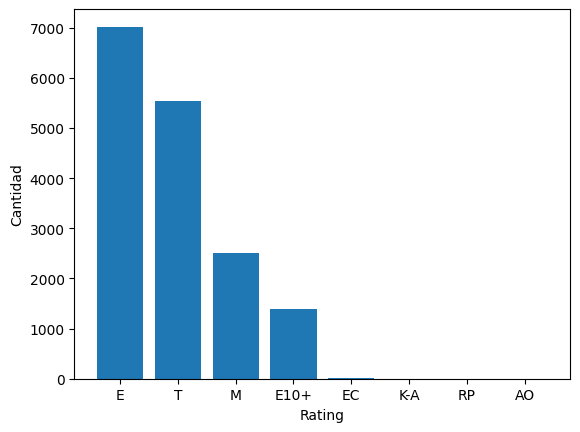

In [94]:
# Grafico serie rating
import matplotlib.pyplot as plt
plt.bar(graf_rat.index, 
        graf_rat.values, 
        label="Rating Imputados")
plt.xlabel("Rating")
plt.ylabel("Cantidad")
plt.show()

In [95]:
df_games=df.copy()
df_games = df_games.drop(
    columns=[
        "rating_imputado_genre_brand",
        "rating_imputado_brand",
        "rating_imputado_genre",
        "median_cr_score",
        "median_user_score"
    ],errors="ignore"
)

In [96]:
df_games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,brand
0,wii sports,WII,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,Nintendo
1,super mario bros,NES,1985,Platform,29.08,3.58,6.81,0.77,69.5,7.7,E,40.24,Nintendo
2,mario kart wii,WII,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,Nintendo
3,wii sports resort,WII,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,Nintendo
4,pokemon redpokemon blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,74.0,7.8,T,31.38,Nintendo
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16456,samurai warriors sanada maru,PS3,2016,Action,0.00,0.00,0.01,0.00,68.0,7.4,T,0.01,Sony
16457,lma manager 2,X360,2006,Sports,0.00,0.01,0.00,0.00,75.0,7.4,E,0.01,Microsoft
16458,haitaka no psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,66.0,7.6,M,0.01,Sony
16459,spirits & spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,69.5,7.7,E,0.01,Nintendo


Con la integracion de la columna marca o brand a la base df_games ahora se puede agrupar por marca y para las columnas user_score_num , critic_score y rating para sustituir valores nulos por el promedio y para el caso de ranking por la moda categorica que ocupe al acruparse por brand.

# 2.- Analisis numérico y categorico

En esta sección se realizarqn los calculos y graficos que se permita analizar el data Frame Games, mediante segmentacion y agrupacion de campos como marca, plataforma y ventas. visualizaciones de histograma, gráfico de cajas o bigotes, correlaciones. Géneros y plataformas más vendidos y menos vendidos, tendencia de ventas globales a lo largo de los años.

#  Ventas Globales

In [97]:
# 1) Calcular las ventas totales para cada juego y guardarlas en una columna nueva
# Crear columna de ventas globales
df["global_sales"] = (
    df["na_sales"]
    + df["eu_sales"]
    + df["jp_sales"]
    + df["other_sales"]
)

# Verificar
df[["name","brand","platform", "global_sales"]].head()

,name,brand,platform,global_sales
0,wii sports,Nintendo,WII,82.54
1,super mario bros,Nintendo,NES,40.24
2,mario kart wii,Nintendo,WII,35.52
3,wii sports resort,Nintendo,WII,32.77
4,pokemon redpokemon blue,Nintendo,GB,31.38


In [98]:
df["global_sales"].describe()

count    16461.000000
mean         0.536513
std          1.558740
min          0.000000
25%          0.060000
50%          0.170000
75%          0.470000
max         82.540000
Name: global_sales, dtype: float64

In [99]:
# Percentiles Principales
p01 = df["global_sales"].quantile(0.01)
p05 = df["global_sales"].quantile(0.05)
p10 = df["global_sales"].quantile(0.10)
p50 = df["global_sales"].quantile(0.50)
p90 = df["global_sales"].quantile(0.90)
p95 = df["global_sales"].quantile(0.95)
p99 = df["global_sales"].quantile(0.99)
p999 = df["global_sales"].quantile(0.999)

Q1 = 0.06, Q2 = 0.17, Q3 = 0.47, IQR = 0.41.  
Límite inferior = Q1 - 1.5 IQR.   
Límite superior= Q3 + 1.5 IQR.   
Límite inferior: 0.0.  
Limife superior= 1.085. 

P05 → los más vendidos “los peores”.  
Q2=P50 → promedio (mediana).  
P90 → los “hits”.  
P95–P99 → los mas significativos

In [100]:

def clasificar(x):
    if x >= p95:
        return "top"
    elif x <= p05:
        return "low"
    else:
        return "mid"

df["cat_vtas"] = df["global_sales"].apply(clasificar)


In [101]:
# Tabla de clasificacion de Ventas
df["cat_vtas"].value_counts()

mid    13840
low     1796
top      825
Name: cat_vtas, dtype: int64

In [102]:
# Lista de Productos menos significativos P05
mask_low=df["cat_vtas"]=="low"
df_low=df[mask_low]
df_low

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,median_cr_score,median_user_score,brand,rating_imputado_genre_brand,rating_imputado_brand,rating_imputado_genre,cat_vtas
14211,game of thrones (telltale),X360,2015,Adventure,0.02,0.00,0.00,0.0,66.0,7.6,M,0.02,66.0,7.6,Microsoft,M,T,E,low
14238,house md,DS,2010,Adventure,0.02,0.00,0.00,0.0,66.0,7.6,T,0.02,66.0,7.6,Nintendo,E,E,E,low
14300,ratatouille,PC,2007,Action,0.01,0.01,0.00,0.0,68.0,7.9,E,0.02,68.0,7.4,Pc,M,T,T,low
14302,rabbids land,WIIU,2012,Misc,0.01,0.01,0.00,0.0,52.0,5.2,E10+,0.02,69.0,7.1,Nintendo,E,E,E,low
14317,slai steel lancer arena international,PS2,2005,Simulation,0.01,0.01,0.00,0.0,66.0,7.8,T,0.02,70.0,7.5,Sony,T,T,E,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16456,samurai warriors sanada maru,PS3,2016,Action,0.00,0.00,0.01,0.0,68.0,7.4,T,0.01,68.0,7.4,Sony,T,T,T,low
16457,lma manager 2,X360,2006,Sports,0.00,0.01,0.00,0.0,75.0,7.4,E,0.01,75.0,7.4,Microsoft,E,T,E,low
16458,haitaka no psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.0,66.0,7.6,M,0.01,66.0,7.6,Sony,M,T,E,low
16459,spirits & spells,GBA,2003,Platform,0.01,0.00,0.00,0.0,69.5,7.7,E,0.01,69.5,7.7,Nintendo,E,E,E,low


In [103]:
# Lista de Productos menos significativos P99
mask_top=df["cat_vtas"]=="top"
df_top=df[mask_top]
df_top

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,median_cr_score,median_user_score,brand,rating_imputado_genre_brand,rating_imputado_brand,rating_imputado_genre,cat_vtas
0,wii sports,WII,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,75.0,7.4,Nintendo,E,E,E,top
1,super mario bros,NES,1985,Platform,29.08,3.58,6.81,0.77,69.5,7.7,E,40.24,69.5,7.7,Nintendo,E,E,E,top
2,mario kart wii,WII,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,69.0,7.4,Nintendo,E,E,E,top
3,wii sports resort,WII,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,75.0,7.4,Nintendo,E,E,E,top
4,pokemon redpokemon blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,74.0,7.8,T,31.38,74.0,7.8,Nintendo,T,E,T,top
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,ghostbusters the video game (ds version),PS3,2010,Action,0.60,0.96,0.13,0.36,68.0,7.4,T,2.05,68.0,7.4,Sony,T,T,T,top
821,madden nfl 15,X360,2014,Sports,1.77,0.06,0.00,0.22,75.0,5.5,E,2.05,75.0,7.4,Microsoft,E,T,E,top
822,need for speed undercover,PS3,2008,Racing,0.63,1.00,0.05,0.38,59.0,5.9,T,2.06,69.0,7.4,Sony,E,T,E,top
823,toy story 3 the video game,DS,2010,Action,0.89,0.94,0.02,0.21,68.0,7.4,E,2.06,68.0,7.4,Nintendo,E,E,T,top


In [104]:
# Lista de productos centrales
mask_mid=df["cat_vtas"]=="mid"
df_mid=df[mask_mid]
df_mid

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,median_cr_score,median_user_score,brand,rating_imputado_genre_brand,rating_imputado_brand,rating_imputado_genre,cat_vtas
825,socom us navy seals combined assault,PS2,2006,Shooter,1.74,0.02,0.00,0.28,72.0,9.0,T,2.04,73.0,7.4,Sony,M,T,M,mid
826,peter jacksons king kong the official game of ...,PS2,2005,Action,0.71,1.02,0.00,0.31,82.0,8.2,T,2.04,68.0,7.4,Sony,T,T,T,mid
827,need for speed prostreet,PS3,2007,Racing,0.73,0.91,0.04,0.36,73.0,6.0,E10+,2.04,69.0,7.4,Sony,E,T,E,mid
828,donkey kong country,GBA,2003,Platform,1.20,0.48,0.29,0.07,78.0,8.9,E,2.04,69.5,7.7,Nintendo,E,E,E,mid
829,dance central 2,X360,2011,Misc,1.45,0.41,0.01,0.16,86.0,8.2,T,2.03,69.0,7.1,Microsoft,T,T,E,mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14920,demikids dark version,GBA,2002,Role-Playing,0.02,0.01,0.00,0.00,74.0,7.8,T,0.03,74.0,7.8,Nintendo,T,E,T,mid
14924,blender bros,GBA,2002,Platform,0.02,0.01,0.00,0.00,73.0,7.7,E,0.03,69.5,7.7,Nintendo,E,E,E,mid
14929,demikids light version,GBA,2002,Role-Playing,0.02,0.01,0.00,0.00,62.0,8.3,E,0.03,74.0,7.8,Nintendo,T,E,T,mid
14977,summon night swordcraft story,GBA,2003,Role-Playing,0.02,0.01,0.00,0.00,77.0,8.1,E10+,0.03,74.0,7.8,Nintendo,T,E,T,mid


In [105]:
# Producto con venta maxima
mask_max=df["global_sales"]>82
df_max=df[mask_max]
df_max

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,median_cr_score,median_user_score,brand,rating_imputado_genre_brand,rating_imputado_brand,rating_imputado_genre,cat_vtas
0,wii sports,WII,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,75.0,7.4,Nintendo,E,E,E,top


In [106]:
# Producto con venta minimas
mask_min=df["global_sales"]==0
df_min=df[mask_min]
df_min

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,median_cr_score,median_user_score,brand,rating_imputado_genre_brand,rating_imputado_brand,rating_imputado_genre,cat_vtas
16422,g1 jockey 4 2008,PS3,2008,Sports,0.0,0.0,0.0,0.0,75.0,7.4,E,0.0,75.0,7.4,Sony,E,T,E,low
16455,score international baja 1000 the official game,PS2,2008,Racing,0.0,0.0,0.0,0.0,69.0,7.4,E,0.0,69.0,7.4,Sony,E,T,E,low


In [107]:
df

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,median_cr_score,median_user_score,brand,rating_imputado_genre_brand,rating_imputado_brand,rating_imputado_genre,cat_vtas
0,wii sports,WII,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,75.0,7.4,Nintendo,E,E,E,top
1,super mario bros,NES,1985,Platform,29.08,3.58,6.81,0.77,69.5,7.7,E,40.24,69.5,7.7,Nintendo,E,E,E,top
2,mario kart wii,WII,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,69.0,7.4,Nintendo,E,E,E,top
3,wii sports resort,WII,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,75.0,7.4,Nintendo,E,E,E,top
4,pokemon redpokemon blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,74.0,7.8,T,31.38,74.0,7.8,Nintendo,T,E,T,top
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16456,samurai warriors sanada maru,PS3,2016,Action,0.00,0.00,0.01,0.00,68.0,7.4,T,0.01,68.0,7.4,Sony,T,T,T,low
16457,lma manager 2,X360,2006,Sports,0.00,0.01,0.00,0.00,75.0,7.4,E,0.01,75.0,7.4,Microsoft,E,T,E,low
16458,haitaka no psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,66.0,7.6,M,0.01,66.0,7.6,Sony,M,T,E,low
16459,spirits & spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,69.5,7.7,E,0.01,69.5,7.7,Nintendo,E,E,E,low


# Juegos por año

In [108]:
# Juegos por año
jgo_year = (
    df["year_of_release"]
    .value_counts()
    .sort_index()
    .reset_index(name="cantidad")
)

jgo_year.columns = ["year_of_release", "jgos_lanzados"]

print(jgo_year)

# Promedio anual (solo cantidad)
jgo_mean = jgo_year["jgos_lanzados"].mean()
print("Promedio:", jgo_mean)

# Desviación estándar
jgo_std = jgo_year["jgos_lanzados"].std()
print("Std:", jgo_std)


    year_of_release  jgos_lanzados
0              1980              9
1              1981             46
2              1982             36
3              1983             17
4              1984             14
5              1985             14
6              1986             21
7              1987             16
8              1988             15
9              1989             17
10             1990             16
11             1991             41
12             1992             43
13             1993             60
14             1994            121
15             1995            219
16             1996            263
17             1997            289
18             1998            379
19             1999            338
20             2000            350
21             2001            482
22             2002            830
23             2003            780
24             2004            764
25             2005            941
26             2006           1008
27             2007 

# Ventas por año

In [109]:
# EstadiStica de ventas de juegos al año

# -------------------------------
# Ventas por año
# -------------------------------
vta_year = (
    df.groupby(["year_of_release"])
    .agg(ventas=("global_sales", "sum"))
    .reset_index()
)
print(vta_year)
# -------------------------------
# Estadística correcta (por año)
# -------------------lo------------
vta_mean = vta_year["ventas"].mean()
vta_std  = vta_year["ventas"].std()
print("media",vta_mean)
print("std",vta_std)


    year_of_release  ventas
0              1980   11.38
1              1981   35.68
2              1982   28.88
3              1983   16.80
4              1984   50.35
5              1985   53.95
6              1986   37.08
7              1987   21.70
8              1988   47.21
9              1989   73.45
10             1990   49.37
11             1991   32.23
12             1992   76.16
13             1993   45.99
14             1994   79.23
15             1995   88.12
16             1996  199.15
17             1997  201.07
18             1998  256.31
19             1999  251.11
20             2000  201.66
21             2001  331.46
22             2002  395.55
23             2003  360.66
24             2004  427.42
25             2005  458.29
26             2006  520.75
27             2007  604.75
28             2008  671.52
29             2009  659.62
30             2010  590.13
31             2011  507.63
32             2012  355.84
33             2013  361.59
34             2014 

## Graficos anuales de cantidad de juegos y ventas

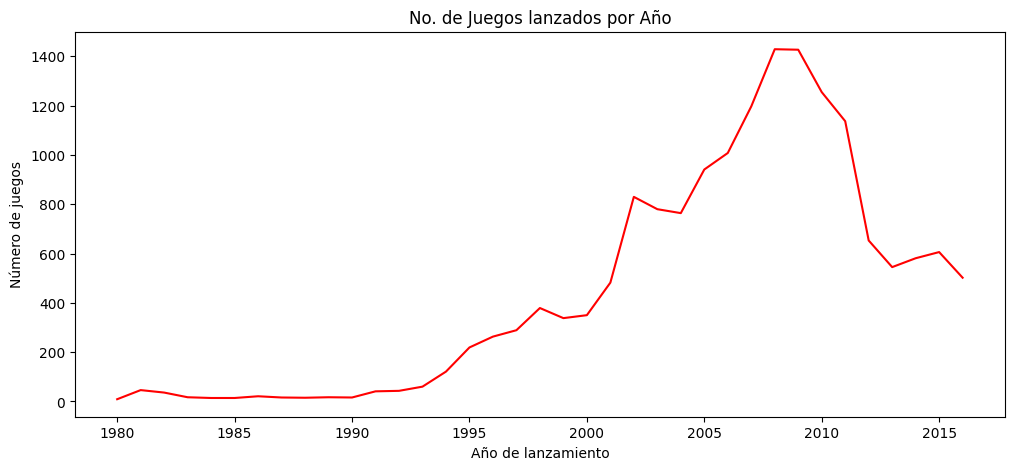

In [110]:
# Grafico de cantidad de juegos lanzados anualmente 
import matplotlib.pyplot as plt
# Grafico de tendencia de ventas de juegos
jgo_year.plot(
    kind="line",
    x="year_of_release",
    y="jgos_lanzados",
    title=("No. de Juegos lanzados por Año"),
    xlabel="Año de lanzamiento",
    ylabel="Número de juegos",
    color="red",
    figsize=(12,5),
    legend=False
)
plt.show()

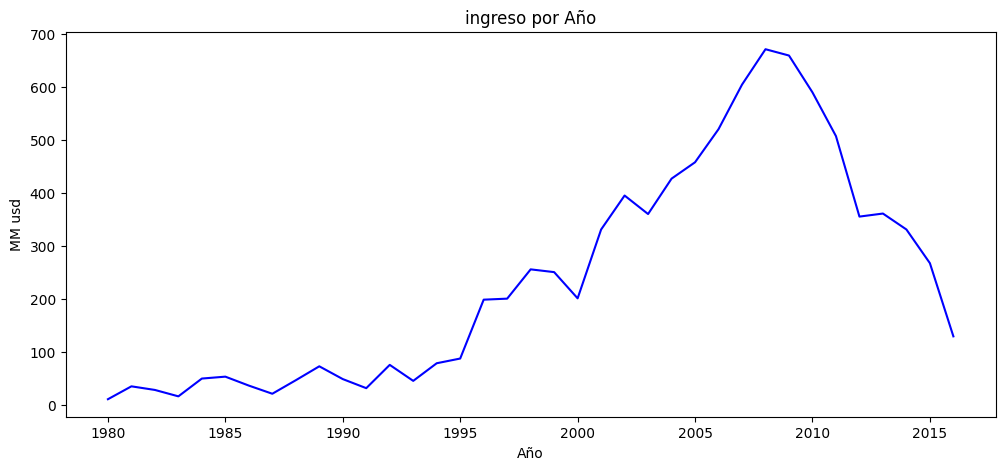

In [111]:
# Grafico de ingreso anual por venta de juegos
import matplotlib.pyplot as plt
# Grafico de tendencia de ventas de juegos
vta_year.plot(
    kind="line",
    x="year_of_release",
    y="ventas",
    title=("ingreso por Año"),
    xlabel="Año",
    ylabel="MM usd",
    color="blue",
    figsize=(12,5),
    legend=False
)
plt.show()

# Popularidad anual de juegos

In [112]:
pop=vta_year.merge(
    jgo_year,on="year_of_release",how="left")
pop["popularidad"]=vta_year["ventas"]/jgo_year["jgos_lanzados"]
pop

,year_of_release,ventas,jgos_lanzados,popularidad
0,1980,11.38,9,1.264444
1,1981,35.68,46,0.775652
2,1982,28.88,36,0.802222
3,1983,16.80,17,0.988235
4,1984,50.35,14,3.596429
5,1985,53.95,14,3.853571
6,1986,37.08,21,1.765714
7,1987,21.70,16,1.35625
8,1988,47.21,15,3.147333
9,1989,73.45,17,4.320588


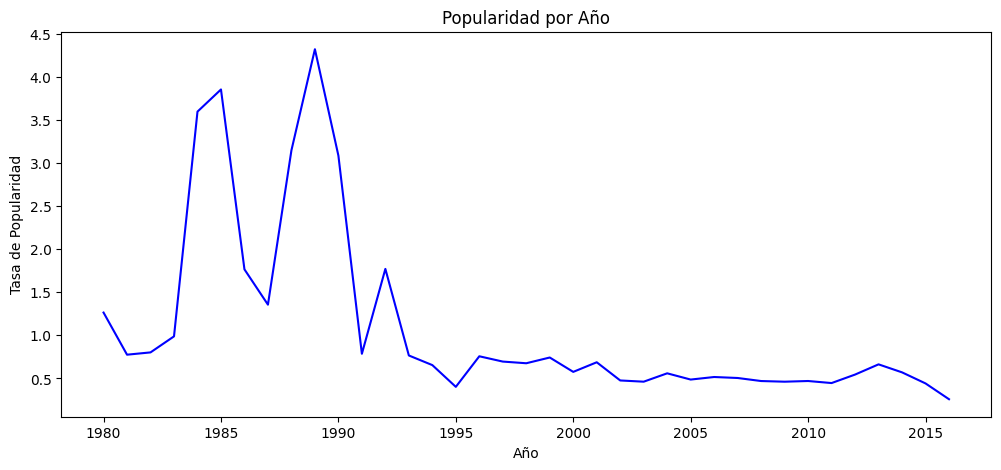

In [113]:
# Grafico de popularidad
import matplotlib.pyplot as plt

pop.plot(
    kind="line",
    x="year_of_release",
    y="popularidad",
    title=("Popularidad por Año"),
    xlabel="Año",
    ylabel="Tasa de Popularidad",
    color="blue",
    figsize=(12,5),
    legend=False
)
plt.show()

Del grafico de popularidad de juegos (razon entre las ventas y cantidad de juegos por año), se observa que la popularidad se estabiliza de 1995 a 2015 por lo que para analisis de comportamiento del mercado se realizara este filtro, no sin antes identificar los años, productos y plataformas mas significativas y las menos significativas.

## Analisis Graficos

In [114]:
# Percentiles Principales
p01 = df["global_sales"].quantile(0.01)
p05 = df["global_sales"].quantile(0.05)
p10 = df["global_sales"].quantile(0.10)
p50 = df["global_sales"].quantile(0.50)
p90 = df["global_sales"].quantile(0.90)
p95 = df["global_sales"].quantile(0.95)
p99 = df["global_sales"].quantile(0.99)
p999 = df["global_sales"].quantile(0.999)


In [115]:
# Año, productos y plataformas mas significativos >95%
mk_umbral_max=df["global_sales"]>=p95
df[mk_umbral_max].sort_values(by="global_sales",ascending=False)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,median_cr_score,median_user_score,brand,rating_imputado_genre_brand,rating_imputado_brand,rating_imputado_genre,cat_vtas
0,wii sports,WII,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,75.0,7.4,Nintendo,E,E,E,top
1,super mario bros,NES,1985,Platform,29.08,3.58,6.81,0.77,69.5,7.7,E,40.24,69.5,7.7,Nintendo,E,E,E,top
2,mario kart wii,WII,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,69.0,7.4,Nintendo,E,E,E,top
3,wii sports resort,WII,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,75.0,7.4,Nintendo,E,E,E,top
4,pokemon redpokemon blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,74.0,7.8,T,31.38,74.0,7.8,Nintendo,T,E,T,top
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,pokemon mystery dungeon redblue rescue team,GBA,2005,Role-Playing,0.71,0.52,0.74,0.08,74.0,7.8,T,2.05,74.0,7.8,Nintendo,T,E,T,top
820,ghostbusters the video game (ds version),PS3,2010,Action,0.60,0.96,0.13,0.36,68.0,7.4,T,2.05,68.0,7.4,Sony,T,T,T,top
816,tom clancys splinter cell conviction,X360,2010,Action,1.20,0.62,0.04,0.19,68.0,7.4,M,2.05,68.0,7.4,Microsoft,M,T,T,top
815,kingdom hearts birth by sleep,PSP,2010,Role-Playing,0.63,0.41,0.75,0.26,82.0,8.6,E10+,2.05,74.0,7.8,Sony,T,T,T,top


In [116]:
# Año , producto y plataformq menos significativos
mk_umbral_min=df["global_sales"]<=p05
df[mk_umbral_min].sort_values(by="global_sales",ascending=False)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales,median_cr_score,median_user_score,brand,rating_imputado_genre_brand,rating_imputado_brand,rating_imputado_genre,cat_vtas
14211,game of thrones (telltale),X360,2015,Adventure,0.02,0.00,0.00,0.0,66.0,7.6,M,0.02,66.0,7.6,Microsoft,M,T,E,low
15356,hogs of war,PS,2000,Strategy,0.01,0.01,0.00,0.0,62.0,8.8,T,0.02,73.0,7.8,Sony,T,T,T,low
15339,dark tales edgar allan poes the premature burial,PC,2012,Puzzle,0.00,0.02,0.00,0.0,70.0,7.5,E,0.02,70.0,7.5,Pc,E,T,E,low
15340,aoishiro,PS2,2008,Adventure,0.00,0.00,0.02,0.0,66.0,7.6,M,0.02,66.0,7.6,Sony,M,T,E,low
15341,mount & blade warband,PC,2010,Role-Playing,0.01,0.01,0.00,0.0,74.0,7.8,M,0.02,74.0,7.8,Pc,M,T,T,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15938,uta no * princesama sweet serenade,PSP,2011,Adventure,0.00,0.00,0.01,0.0,66.0,7.6,M,0.01,66.0,7.6,Sony,M,T,E,low
15939,higurashi no naku koro ni iki,PS3,2015,Action,0.00,0.00,0.01,0.0,68.0,7.4,T,0.01,68.0,7.4,Sony,T,T,T,low
16460,winning post 8 2016,PSV,2016,Simulation,0.00,0.00,0.01,0.0,70.0,7.5,T,0.01,70.0,7.5,Sony,T,T,E,low
16422,g1 jockey 4 2008,PS3,2008,Sports,0.00,0.00,0.00,0.0,75.0,7.4,E,0.00,75.0,7.4,Sony,E,T,E,low


In [117]:
# Resumen de plataformas mas significativas
sumary_top=df.loc[df["cat_vtas"] == "top"] \
  .groupby(["platform", "year_of_release"]) \
  .agg(
      total_ventas=("global_sales", "sum"),
      num_juegos=("global_sales", "count")
  ) \
  .reset_index()
print(sumary_top.value_counts())

platform  year_of_release  total_ventas  num_juegos
2600      1980             7.07          2             1
PS4       2014             65.55         14            1
PS3       2011             76.08         17            1
          2012             47.07         10            1
          2013             62.23         11            1
                                                      ..
N64       1998             18.50         5             1
          1997             19.87         4             1
          1996             27.36         4             1
GEN       1992             10.74         3             1
XONE      2016             9.49          4             1
Length: 142, dtype: int64


In [118]:
sumary_top["platform"].unique()
for p in sumary_top["platform"].unique():
    print(p)

2600
3DS
DC
DS
GB
GBA
GC
GEN
N64
NES
PC
PS
PS2
PS3
PS4
PSP
SNES
WII
WIIU
X360
XB
XONE


In [119]:
# Resumen de plataformas menos significativas
sumary_low=df.loc[df["cat_vtas"] == "low"] \
  .groupby(["year_of_release","platform"]) \
  .agg(
      total_ventas=("global_sales", "sum"),
      num_juegos=("global_sales", "count")
  ) \
  .reset_index()
print(sumary_low.value_counts())

year_of_release  platform  total_ventas  num_juegos
1985             DS        0.02          1             1
2010             X360      0.23          13            1
2011             DS        0.36          21            1
                 PC        0.41          26            1
                 PS2       0.03          2             1
                                                      ..
2005             PC        0.27          16            1
                 PS2       0.20          10            1
                 PSP       0.07          4             1
                 X360      0.01          1             1
2016             XONE      0.36          28            1
Length: 149, dtype: int64


In [120]:
# Listado de plataformas no significativos
sumary_low["platform"].unique()
for p in sumary_low["platform"].unique():
    print(p)

DS
PC
SNES
3DO
SAT
NG
PS
TG16
N64
GBA
PS2
GC
XB
PSP
X360
PS3
WII
DC
3DS
PSV
WIIU
PS4
XONE


In [121]:
# Estadistica de productos top
top_juegos = df[
    df["global_sales"] > p95
]
top_juegos["global_sales"].describe()

count    820.000000
mean       4.816732
std        5.155403
min        2.050000
25%        2.510000
50%        3.310000
75%        5.022500
max       82.540000
Name: global_sales, dtype: float64

In [122]:
# Estadistica de productos low
low_juegos = df[
    df["global_sales"]< p05]
low_juegos["global_sales"].describe()


count    782.000000
mean       0.009974
std        0.000505
min        0.000000
25%        0.010000
50%        0.010000
75%        0.010000
max        0.010000
Name: global_sales, dtype: float64

In [123]:
# Estadistica de productos promedio
mid_juegos = df[
    (df["global_sales"] >= p05) &  (df["global_sales"]<= p95)]
mid_juegos["global_sales"].describe()


count    14859.000000
mean         0.328018
std          0.396811
min          0.020000
25%          0.070000
50%          0.170000
75%          0.420000
max          2.050000
Name: global_sales, dtype: float64

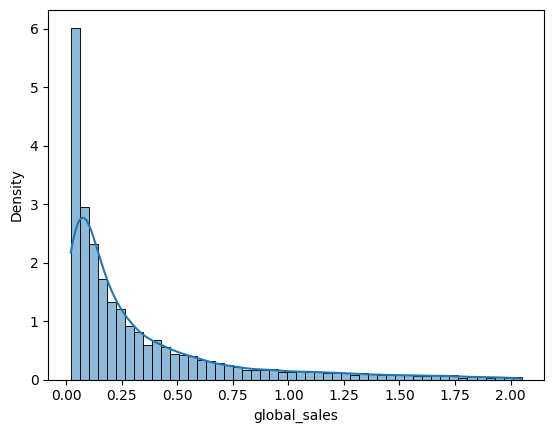

In [124]:
# Grafico de juegos promedios
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    mid_juegos["global_sales"],
    bins=50,          # más limpio
    kde=True,
    stat="density"    # escala consistente con KDE
)
plt.show()

In [125]:
# Estadistica de productos promedio
mid_juegos = df[
    (df["global_sales"] > p05) &
    (df["global_sales"] < p95)
]
mid_juegos["global_sales"].describe()

count    13840.000000
mean         0.349963
std          0.400685
min          0.030000
25%          0.080000
50%          0.190000
75%          0.450000
max          2.040000
Name: global_sales, dtype: float64

# Analisis de reseñas de video juegos
ventas globales, user_score y critic_score

In [126]:
import pandas as pd
import matplotlib.pyplot as plt

# Seleccionar columnas para correlación 
corr_df = df[["global_sales", "critic_score", "user_score"]].copy()

# Matriz de correlacióno
corr_matrix = corr_df.corr()

print("Matriz de correlación:")
print(corr_matrix)

Matriz de correlación:
              global_sales  critic_score  user_score
global_sales      1.000000      0.196488    0.055019
critic_score      0.196488      1.000000    0.467524
user_score        0.055019      0.467524    1.000000


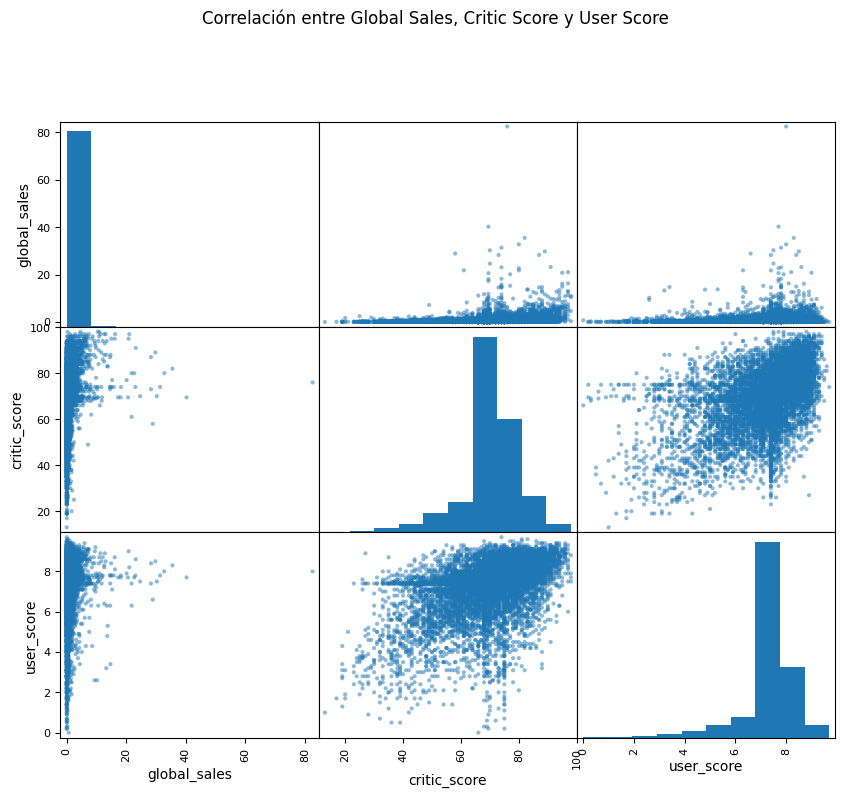

In [127]:
# Gráfico de dispersión entre variables
pd.plotting.scatter_matrix(
    corr_df,
    figsize=(10, 8),
    diagonal="hist",
    alpha=0.5
)
plt.suptitle("Correlación entre Global Sales, Critic Score y User Score", y=1.02)
plt.show()

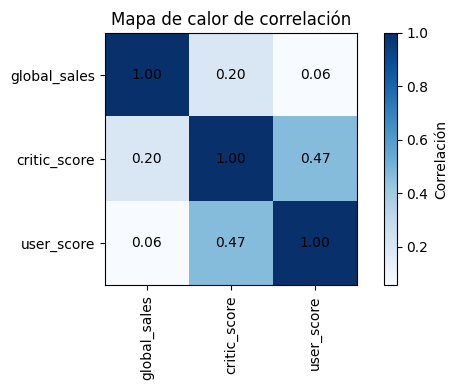

In [128]:
# Mapa de calor simple con matplotlib

plt.figure(figsize=(6, 4))
plt.imshow(corr_matrix, cmap="Blues", interpolation="nearest")
plt.colorbar(label="Correlación")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

# Mostrar valores dentro del mapa
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.title("Mapa de calor de correlación")
plt.tight_layout()
plt.show()

### No se observa que las criticas por parte de los expertos o usuarios no afectan a las ventas, posiblemente sea mas afectado por el prestigio de la marca

## Analisis estadistico e inferencial para verificar si la marca influencia en las ventas

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16461 entries, 0 to 16460
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         16461 non-null  object 
 1   platform                     16461 non-null  object 
 2   year_of_release              16461 non-null  Int64  
 3   genre                        16461 non-null  object 
 4   na_sales                     16461 non-null  float64
 5   eu_sales                     16461 non-null  float64
 6   jp_sales                     16461 non-null  float64
 7   other_sales                  16461 non-null  float64
 8   critic_score                 16461 non-null  float64
 9   user_score                   16461 non-null  float64
 10  rating                       16461 non-null  string 
 11  global_sales                 16461 non-null  float64
 12  median_cr_score              16461 non-null  float64
 13  median_user_scor

In [130]:
#1
import pandas as pd
import numpy as np

In [131]:
#2
ventas_brand = (
    df.groupby("brand")["global_sales"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

print(ventas_brand)

             count      mean  median       std
brand                                         
Atari          116  0.745517   0.480  0.956160
Microsoft     2286  0.600731   0.220  1.303693
Nintendo      6171  0.561888   0.160  2.094148
Sony          6647  0.536382   0.190  1.117663
Psega            6  0.310000   0.065  0.584055
Sega           253  0.308024   0.120  0.611684
Pc             958  0.267338   0.050  0.679395
Bandai           6  0.236667   0.215  0.159457
Snk             12  0.120000   0.100  0.082241
Nec              3  0.063333   0.030  0.066583
3Do Company      3  0.033333   0.020  0.023094


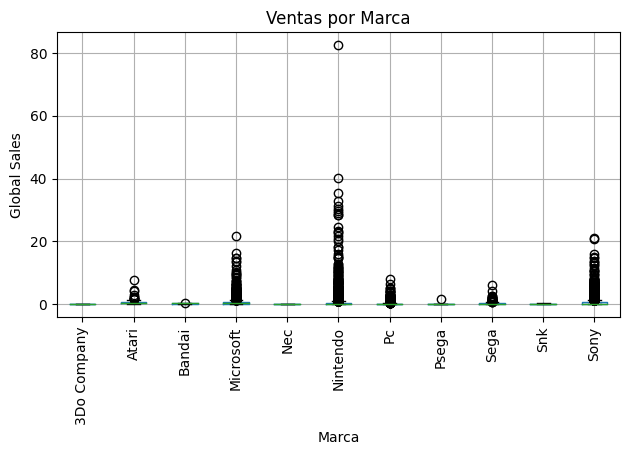

In [132]:
#3
import matplotlib.pyplot as plt

# Ordenar por promedio para mejor lectura
orden = df.groupby("brand")["global_sales"].mean().sort_values().index

df.boxplot(column="global_sales", by="brand")

plt.xticks(rotation=90)
plt.title("Ventas por Marca")
plt.suptitle("")
plt.xlabel("Marca")
plt.ylabel("Global Sales")

plt.tight_layout()
plt.show()

In [133]:
#4
from scipy import stats

# Crear lista de grupos por marca
grupos = [grupo["global_sales"].values for _, grupo in df.groupby("brand")]

# ANOVA
f_stat, p_val = stats.f_oneway(*grupos)

print("F-stat:", f_stat)
print("p-value:", p_val)

F-stat: 4.348869283077386
p-value: 4.145125064629951e-06


Como p < 0.05 → La marca sí afecta las ventas
Las principales son  Nintendo , Microsoft y Sony.

# Plataformas de Nintendo mas vendidas 

In [134]:
import pandas as pd

# Filtrar Nintendo
df_nintendo = df[df["brand"] == "Nintendo"].copy()

# Ventas totales por plataforma
ventas_plataforma_nintendo = (
    df_nintendo.groupby(["brand","platform"])["global_sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="ventas_totales")
)

ventas_plataforma_nintendo
top_nintendo=ventas_plataforma_nintendo.head(2)
top_nintendo

,brand,platform,ventas_totales
0,Nintendo,WII,891.18
1,Nintendo,DS,802.79


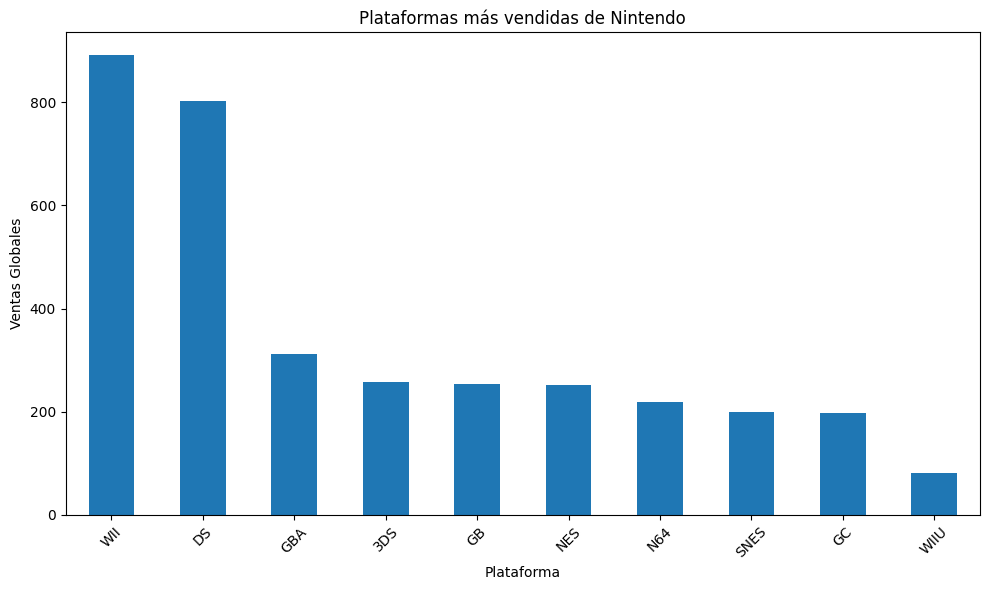

In [135]:
import matplotlib.pyplot as plt

ventas_plataforma_nintendo.plot(
    kind="bar",
    x="platform",
    y="ventas_totales",
    figsize=(10, 6),
    legend=False,
    title="Plataformas más vendidas de Nintendo"
)

plt.xlabel("Plataforma")
plt.ylabel("Ventas Globales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [136]:
import pandas as pd

# Filtrar Sony
df_sony = df[df["brand"] == "Sony"].copy()

# Ventas totales por plataforma
ventas_plataforma_sony = (
    df_sony.groupby(["brand","platform"])["global_sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="ventas_totales")
)

ventas_plataforma_sony
top_sony=ventas_plataforma_sony.head(3)
top_sony

,brand,platform,ventas_totales
0,Sony,PS2,1248.12
1,Sony,PS3,931.34
2,Sony,PS,727.58


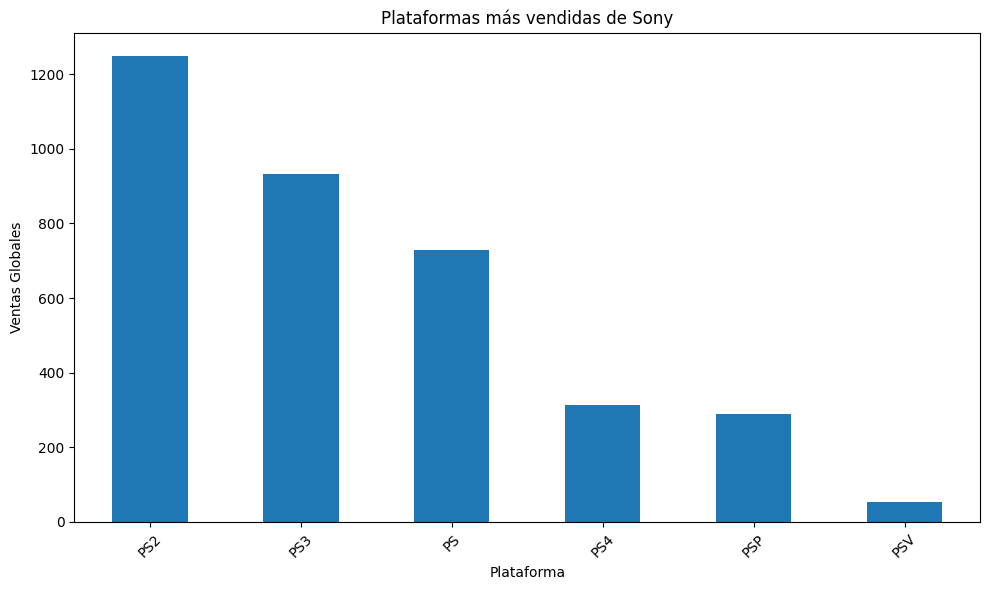

In [137]:
import matplotlib.pyplot as plt

ventas_plataforma_sony.plot(
    kind="bar",
    x="platform",
    y="ventas_totales",
    figsize=(10, 6),
    legend=False,
    title="Plataformas más vendidas de Sony"
)

plt.xlabel("Plataforma")
plt.ylabel("Ventas Globales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [138]:
import pandas as pd

# Filtrar Microsoft
df_microsoft = df[df["brand"] == "Microsoft"].copy()

# Ventas totales por plataforma
ventas_plataforma_microsoft= (
    df_microsoft.groupby(["brand","platform"])["global_sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="ventas_totales")
)

ventas_plataforma_microsoft
top_microsoft=ventas_plataforma_microsoft.head(1)
top_microsoft

,brand,platform,ventas_totales
0,Microsoft,X360,961.29


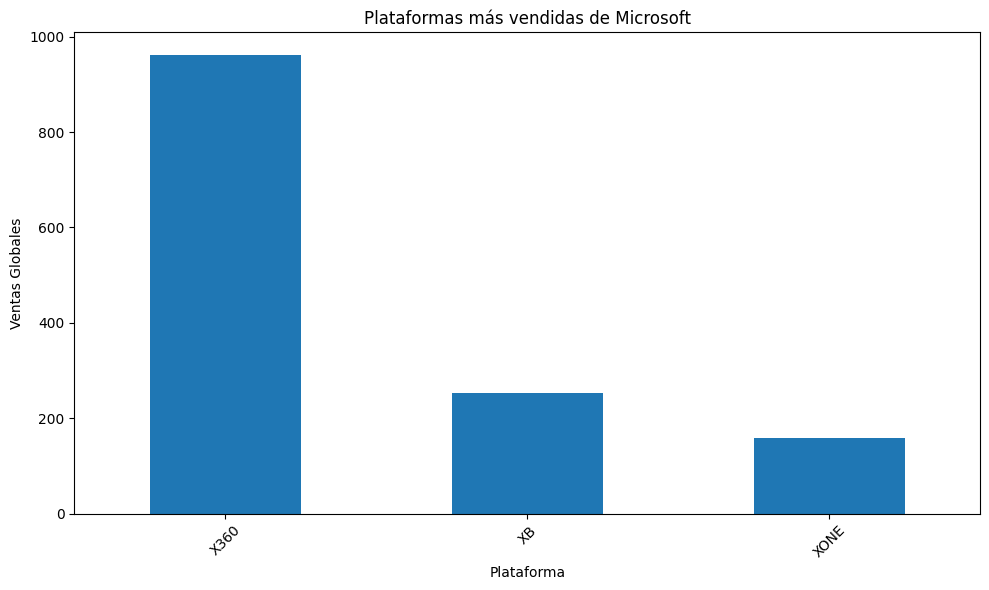

In [139]:
import matplotlib.pyplot as plt

ventas_plataforma_microsoft.plot(
    kind="bar",
    x="platform",
    y="ventas_totales",
    figsize=(10, 6),
    legend=False,
    title="Plataformas más vendidas de Microsoft"
)

plt.xlabel("Plataforma")
plt.ylabel("Ventas Globales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [140]:
# Plataformaa Principales
import pandas as pd

top_total = pd.concat(
    [top_nintendo, top_sony, top_microsoft],
    axis=0,
    ignore_index=True
).sort_values(by="ventas_totales",ascending=False)

print(top_total)

       brand platform  ventas_totales
2       Sony      PS2         1248.12
5  Microsoft     X360          961.29
3       Sony      PS3          931.34
0   Nintendo      WII          891.18
1   Nintendo       DS          802.79
4       Sony       PS          727.58


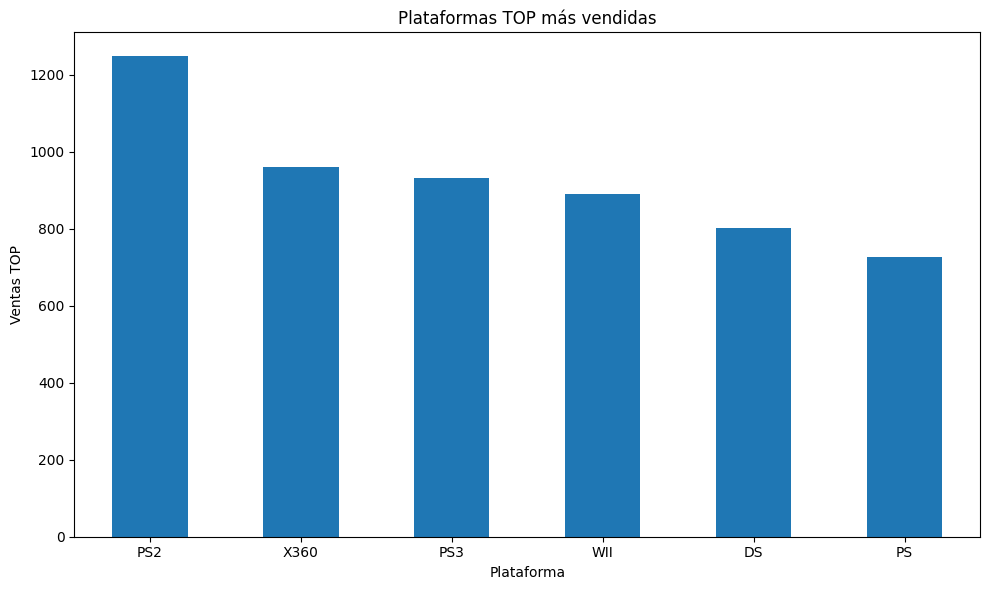

In [141]:
import matplotlib.pyplot as plt

top_total.plot(
    kind="bar",
    x="platform",
    y="ventas_totales",
    figsize=(10, 6),
    legend=False,
    title="Plataformas TOP más vendidas"
)

plt.xlabel("Plataforma")
plt.ylabel("Ventas TOP")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Analisis Regional

In [142]:
# Tabla general de ventas peomedio en Años estables

vta_mid = (
    mid_juegos.groupby(["year_of_release"])
    .agg(ventas=("global_sales", "sum"))
    .reset_index()
)
print(vta_mid)

    year_of_release  ventas
0              1980    4.31
1              1981   26.85
2              1982   21.07
3              1983    9.18
4              1984   11.71
5              1985   10.19
6              1986   17.40
7              1987    7.19
8              1988    8.46
9              1989   13.42
10             1990    9.71
11             1991   23.29
12             1992   13.75
13             1993   32.44
14             1994   43.32
15             1995   53.32
16             1996   86.55
17             1997  110.82
18             1998  146.15
19             1999  137.80
20             2000  124.02
21             2001  171.76
22             2002  238.02
23             2003  255.26
24             2004  268.80
25             2005  278.32
26             2006  233.84
27             2007  335.20
28             2008  430.53
29             2009  368.14
30             2010  311.23
31             2011  282.92
32             2012  199.40
33             2013  173.87
34             2014 

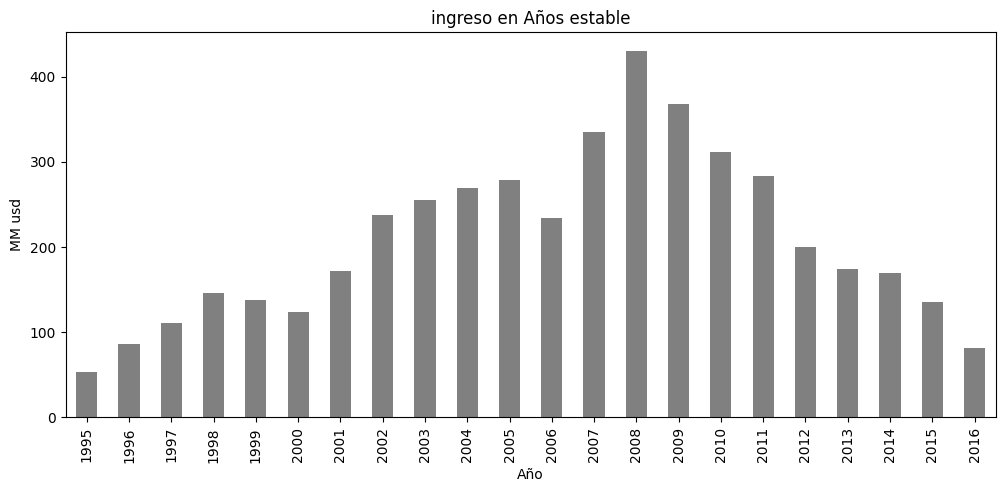

count     22.000000
mean     208.690909
std       99.858956
min       53.320000
25%      135.580000
50%      186.635000
75%      275.940000
max      430.530000
Name: ventas, dtype: float64

In [143]:
# Grafico de venta general de años estables

import matplotlib.pyplot as plt

mk_vta_mid_est=vta_mid["year_of_release"]>=1995
vta_mid_est=vta_mid[mk_vta_mid_est]

vta_mid_est.plot(
    kind="bar",
    x="year_of_release",
    y="ventas",
    title=("ingreso en Años estable"),
    xlabel="Año",
    ylabel="MM usd",
    color="gray",
    figsize=(12,5),
    legend=False
)
plt.show()
vta_mid_est["ventas"].describe()

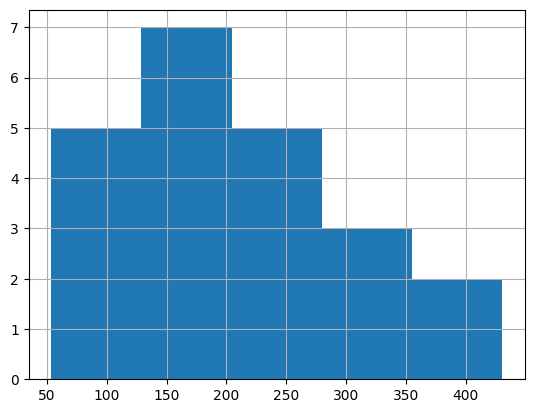

In [144]:
# Histograma
vta_mid_est["ventas"].hist(bins=5);

## Region ja

In [145]:
p01 = df["jp_sales"].quantile(0.01)
p05 = df["jp_sales"].quantile(0.05)
p10 = df["jp_sales"].quantile(0.10)
p25 = df["jp_sales"].quantile(0.25)
p50 = df["jp_sales"].quantile(0.50)
p75 = df["jp_sales"].quantile(0.75)
p90 = df["jp_sales"].quantile(0.90)
p95 = df["jp_sales"].quantile(0.95)
p99 = df["jp_sales"].quantile(0.99)
p999 = df["jp_sales"].quantile(0.999)
irq=p75-p25
qmin=0
qmax=1.5*irq+p75

In [146]:
mid_jp = df[
    (df["jp_sales"] >= qmin) &  (df["jp_sales"]<= qmax)]
mid_jp["jp_sales"].describe()

count    14044.000000
mean         0.010663
std          0.022372
min          0.000000
25%          0.000000
50%          0.000000
75%          0.010000
max          0.100000
Name: jp_sales, dtype: float64

## Region na

In [147]:
p01 = df["na_sales"].quantile(0.01)
p05 = df["na_sales"].quantile(0.05)
p10 = df["na_sales"].quantile(0.10)
p25 = df["na_sales"].quantile(0.25)
p50 = df["na_sales"].quantile(0.50)
p90 = df["na_sales"].quantile(0.90)
p75 = df["na_sales"].quantile(0.75)
p95 = df["na_sales"].quantile(0.95)
p99 = df["na_sales"].quantile(0.99)
p999 = df["na_sales"].quantile(0.999)
irq=p75-p25
qmin=0
qmax=1.5*irq+p75

In [148]:
mid_na = df[
    (df["na_sales"] >= qmin) &  (df["na_sales"]<= qmax)]
mid_na["na_sales"].describe()

count    14794.000000
mean         0.111297
std          0.138580
min          0.000000
25%          0.000000
50%          0.060000
75%          0.160000
max          0.600000
Name: na_sales, dtype: float64

## Region eu

In [149]:
p01 = df["eu_sales"].quantile(0.01)
p05 = df["eu_sales"].quantile(0.05)
p10 = df["eu_sales"].quantile(0.10)
p25 = df["eu_sales"].quantile(0.25)
p50 = df["eu_sales"].quantile(0.50)
p90 = df["eu_sales"].quantile(0.90)
p75 = df["eu_sales"].quantile(0.75)
p95 = df["eu_sales"].quantile(0.95)
p99 = df["eu_sales"].quantile(0.99)
p999 = df["eu_sales"].quantile(0.999)
irq=p75-p25
qmin=0
qmax=1.5*irq+p75

In [150]:
mid_eu = df[
    (df["eu_sales"] >= qmin) &  (df["eu_sales"]<= qmax)]
mid_eu["eu_sales"].describe()

count    14422.000000
mean         0.042777
std          0.062450
min          0.000000
25%          0.000000
50%          0.010000
75%          0.060000
max          0.270000
Name: eu_sales, dtype: float64

## Region others

In [151]:
p01 = df["other_sales"].quantile(0.01)
p05 = df["other_sales"].quantile(0.05)
p10 = df["other_sales"].quantile(0.10)
p25 = df["other_sales"].quantile(0.25)
p50 = df["other_sales"].quantile(0.50)
p75 = df["other_sales"].quantile(0.75)
p90 = df["other_sales"].quantile(0.90)
p95 = df["other_sales"].quantile(0.95)
p99 = df["other_sales"].quantile(0.99)
p999 = df["other_sales"].quantile(0.999)
irq=p75-p25
qmin=0
qmax=1.5*irq+p75

In [152]:
mid_oth= df[
    (df["other_sales"] >= qmin) &  (df["other_sales"]<= qmax)]
mid_oth["other_sales"].describe()

count    14239.000000
mean         0.013283
std          0.017821
min          0.000000
25%          0.000000
50%          0.010000
75%          0.020000
max          0.070000
Name: other_sales, dtype: float64

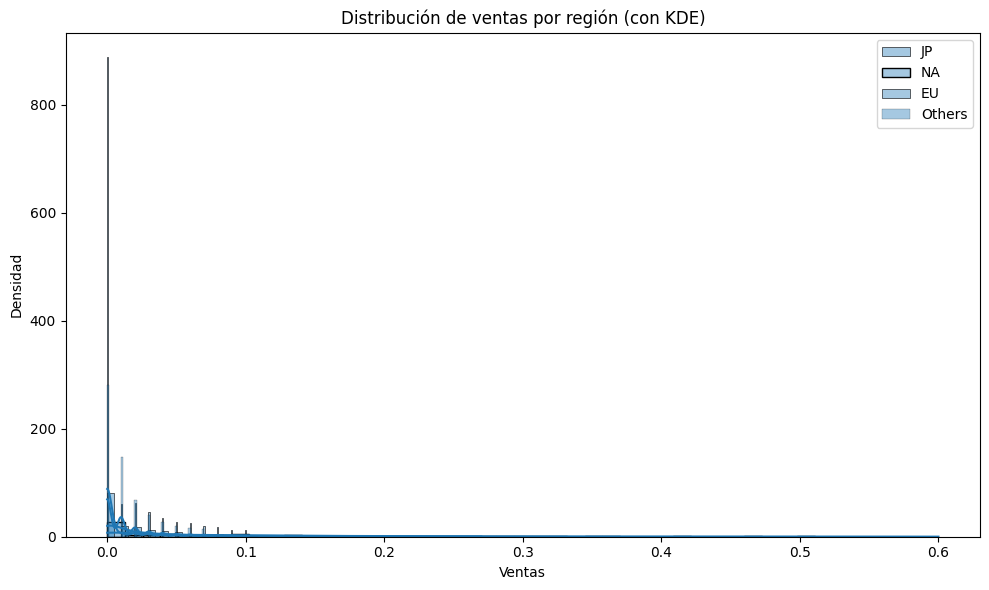

In [153]:
# Graficos de histogramas de densidad interpuestos

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

# Histogramas con KDE
sns.histplot(mid_jp["jp_sales"], kde=True, stat="density", label="JP", alpha=0.4)
sns.histplot(mid_na["na_sales"], kde=True, stat="density", label="NA", alpha=0.4)
sns.histplot(mid_eu["eu_sales"], kde=True, stat="density", label="EU", alpha=0.4)
sns.histplot(mid_oth["other_sales"], kde=True, stat="density", label="Others", alpha=0.4)

# Ajustes
plt.title("Distribución de ventas por región (con KDE)")
plt.xlabel("Ventas")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()

plt.show()

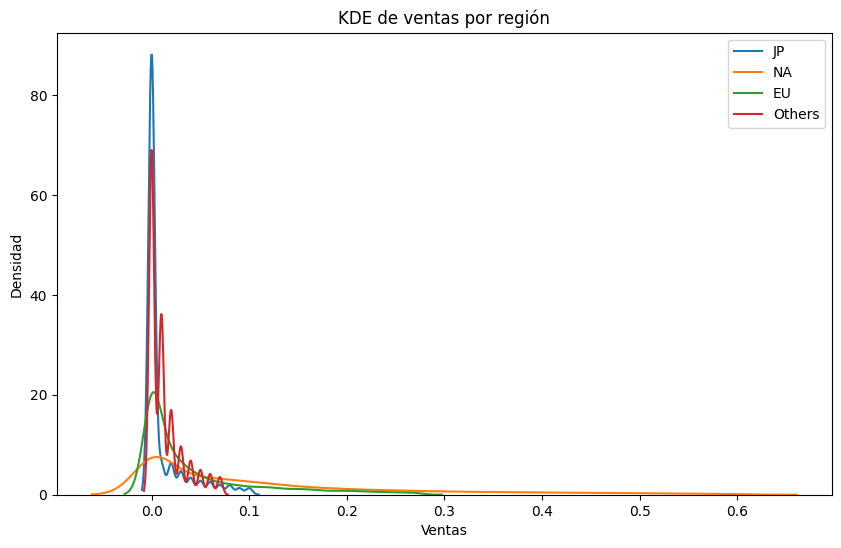

In [154]:
plt.figure(figsize=(10,6))

sns.kdeplot(mid_jp["jp_sales"], label="JP")
sns.kdeplot(mid_na["na_sales"], label="NA")
sns.kdeplot(mid_eu["eu_sales"], label="EU")
sns.kdeplot(mid_oth["other_sales"], label="Others")

plt.title("KDE de ventas por región")
plt.xlabel("Ventas")
plt.ylabel("Densidad")
plt.legend()

plt.show()

In [155]:
#  Pruebas estadisitcq de medias con n igualeS
# ANOVA
# ANOVA asume:
#	1.	Independencia
#	2.	Normalidad (aprox.) datos muy sesgados
#	3.	Varianzas similares

# Ho: medias son iguales
# Ha: medias son diferentes

from scipy import stats

jp = mid_jp["jp_sales"]
na = mid_na["na_sales"]
eu = mid_eu["eu_sales"]
oth = mid_oth["other_sales"]

f_stat, p_value = stats.f_oneway(jp, na, eu, oth)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 5227.104481440582
p-value: 0.0


In [156]:
# Medias regionales 
print("JP:", jp.mean())
print("NA:", na.mean())
print("EU:", eu.mean())
print("Other:", oth.mean())

JP: 0.010662916547992025
NA: 0.11129714749222659
EU: 0.04277700734988213
Other: 0.013283236182316175


In [157]:
# Kruskal-Wallis
# No acecta el sesgo de los datos

# Ho: medias son iguales
# Ha: medias son diferentes

h_stat, p_value = stats.kruskal(jp, na, eu, oth)

print("H-stat:", h_stat)
print("p-value:", p_value)

H-stat: 9864.484226292398
p-value: 0.0


# Conclusiones 

Las plataformas que mas venden son las de las marcas  Nintendo , Sony y Microsoft.   

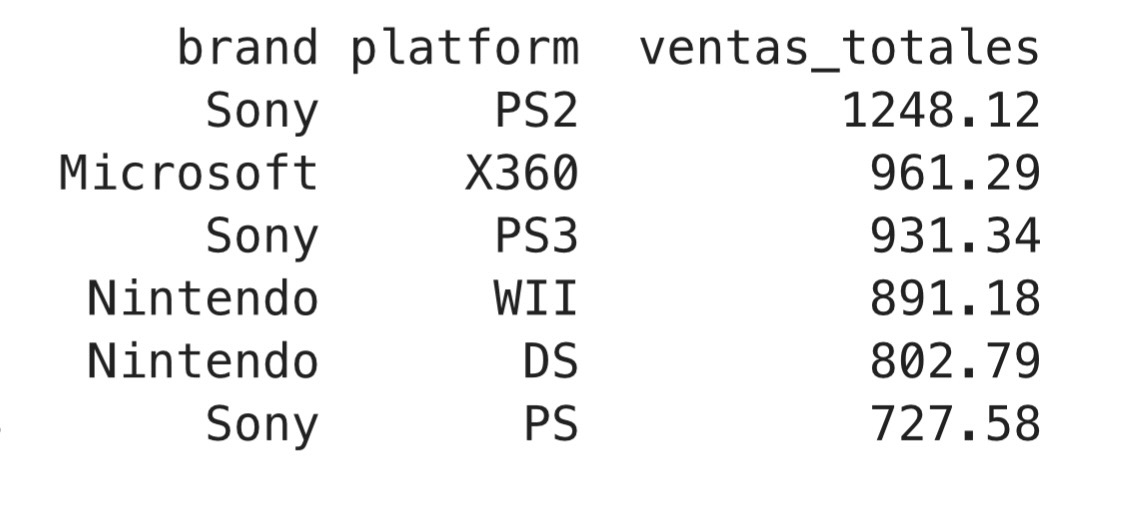.  

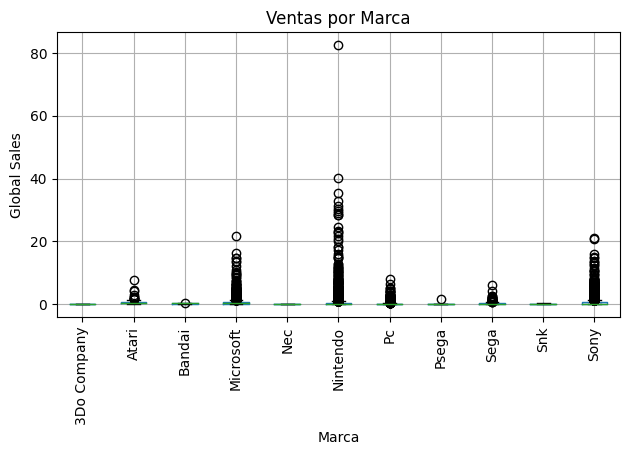

Las plataformas menos significativas son las siguientes:   
['DS', 'PC', 'SNES', '3DO', 'SAT', 'NG', 'PS', 'TG16', 'N64', 'GBA',
       'PS2', 'GC', 'XB', 'PSP', 'X360', 'PS3', 'WII', 'DC', '3DS', 'PSV',
       'WIIU', 'PS4', 'XONE']

La estabilidad de las ventas de juegos y sus ingresos se alcanza apartir de 1995 , los primeros años de los 80's se puede deber al boom que se tuvo por innovacion en el entretenimiento. 

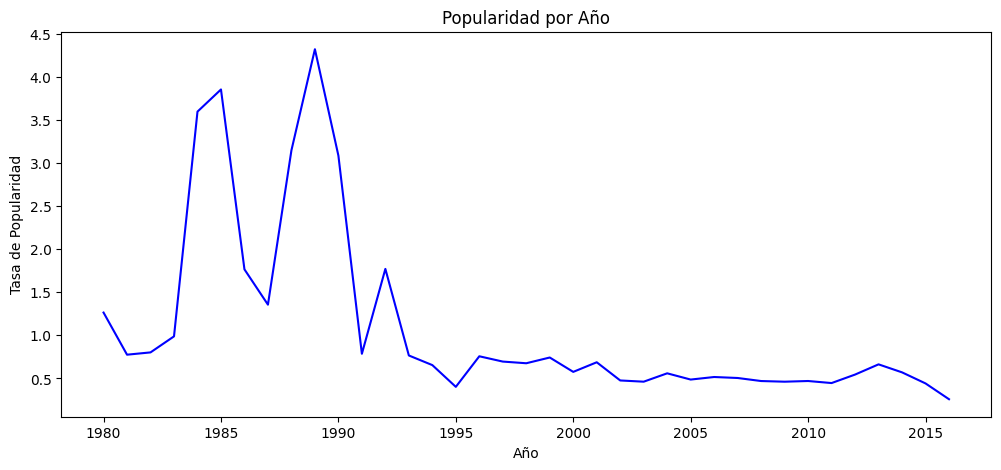

No se observa que las criticas por parte de los expertos o usuarios no afectan a las ventas, posiblemente sea mas afectado por el prestigio de la marca

Distribucion de ventas promedio 

count    13840.000000
mean         0.349963
std          0.400685
min          0.030000
25%          0.080000
50%          0.190000
75%          0.450000
max          2.040000
Name: global_sales, dtype: float64

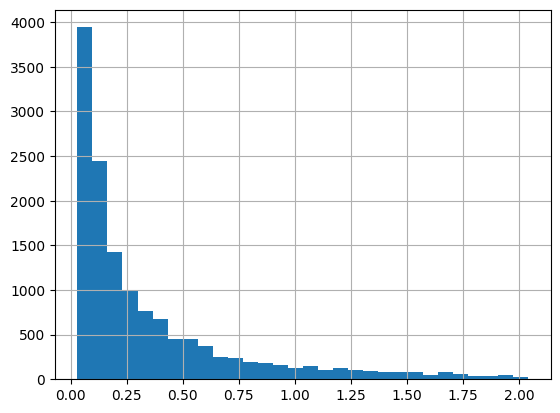

In [158]:
mid_juegos["global_sales"].hist(bins=30);
mid_juegos["global_sales"].describe()

In [159]:
mk_relevantes=mid_juegos["year_of_release"]>=2005
relevantes=mid_juegos[mk_relevantes]

count    9244.000000
mean        0.324394
std         0.379096
min         0.030000
25%         0.080000
50%         0.170000
75%         0.420000
max         2.040000
Name: global_sales, dtype: float64

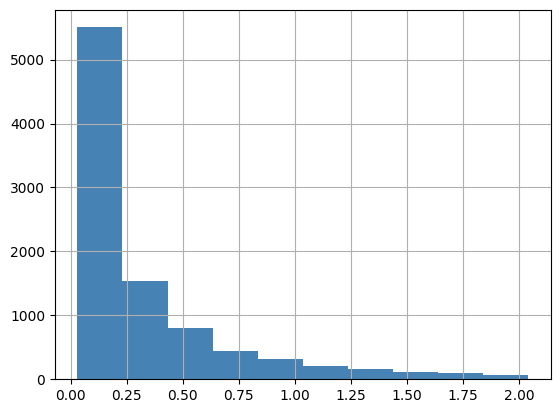

In [160]:
relevantes["global_sales"].hist(color="steelblue");
relevantes["global_sales"].describe()

# Las medias regionales no son iguales
alpha de 0.05

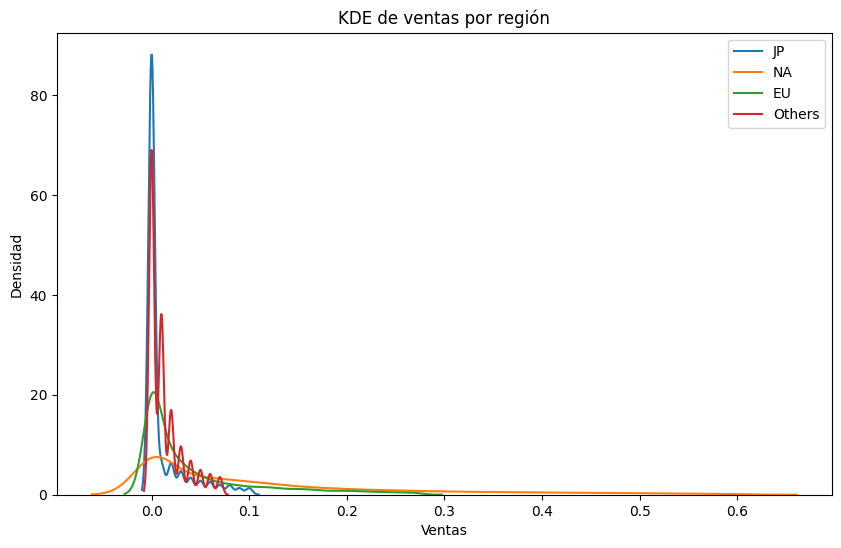

In [161]:
# Medias regionales 
print("Media JP:", jp.mean())
print("Media NA:", na.mean())
print("Media EU:", eu.mean())
print("Media Other:", oth.mean())

Media JP: 0.010662916547992025
Media NA: 0.11129714749222659
Media EU: 0.04277700734988213
Media Other: 0.013283236182316175


# Diagrama de caja por region 

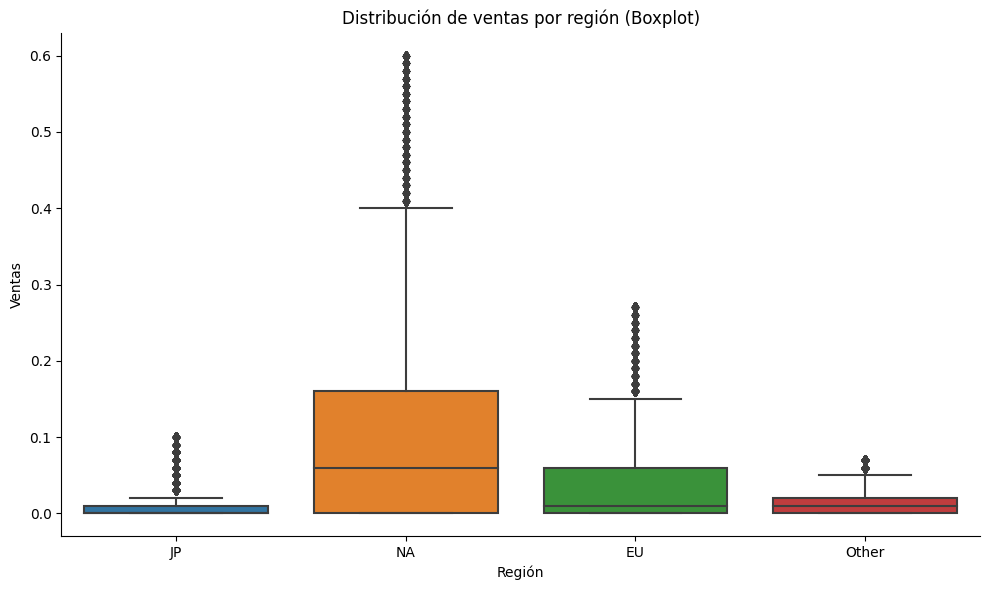

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Formato largo
df_plot = pd.DataFrame({
    "JP": mid_jp["jp_sales"],
    "NA": mid_na["na_sales"],
    "EU": mid_eu["eu_sales"],
    "Other": mid_oth["other_sales"]
}).melt(var_name="Region", value_name="Sales").dropna()

# Gráfico
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_plot,
    x="Region",
    y="Sales"
)

plt.title("Distribución de ventas por región (Boxplot)")
plt.xlabel("Región")
plt.ylabel("Ventas")

sns.despine()
plt.tight_layout()
plt.show()

La region que mas aporta a las ventas es la de america del norte. Tambien es la que tiene mayor variabilidad

## Referente a los valores ausentes de la base de datos se infiere que es por estas causas:
1) No se registró el dato por que El dato nunca se capturó.   
2) El dato no tiene sentido para ese registro
Ejemplo:   
Ventas en Japón = 0 o vacío porque el juego nunca salió ahí.   
3) Falta de disponibilidad histórica.  
Datos antiguos incompletos.  
Ejemplo:   
Juegos viejos sin critic_score

# Perfil de usuario regional (jp,na,eu,other)

## Ventas por genero de las principales marcas

In [163]:
# 1
plataformas = ['DS','PC','SNES','3DO','SAT','NG','PS','TG16',
               'N64','GBA','PS2','GC','XB','PSP','X360','PS3',
               'WII','DC','3DS','PSV','WIIU','PS4','XONE']

df_filtrado = df[df["platform"].isin(plataformas)].copy()

In [164]:
#2 
ventas_genero_region = (
    df_filtrado
    .groupby("genre")[["na_sales", "eu_sales", "jp_sales", "other_sales"]]
    .sum()
    .reset_index()
)

print(ventas_genero_region)

           genre  na_sales  eu_sales  jp_sales  other_sales
0         Action    816.36    503.77    149.75       181.26
1      Adventure     90.07     59.18     46.19        15.77
2       Fighting    214.54     98.12     83.80        36.00
3           Misc    390.15    208.25     98.51        72.75
4       Platform    337.97    175.33     85.71        46.64
5         Puzzle     69.92     41.97     35.16        10.71
6         Racing    348.33    232.57     51.91        75.01
7   Role-Playing    300.19    166.57    301.15        54.57
8        Shooter    533.99    311.69     33.25       102.53
9     Simulation    179.98    113.33     60.11        30.55
10        Sports    662.12    370.90    114.03       133.24
11      Strategy     66.26     44.06     43.04        10.62


In [165]:
#3
ventas_genero_region["region_top"] = (
    ventas_genero_region[["na_sales", "eu_sales", "jp_sales", "other_sales"]]
    .idxmax(axis=1)
)

print(ventas_genero_region)

           genre  na_sales  eu_sales  jp_sales  other_sales region_top
0         Action    816.36    503.77    149.75       181.26   na_sales
1      Adventure     90.07     59.18     46.19        15.77   na_sales
2       Fighting    214.54     98.12     83.80        36.00   na_sales
3           Misc    390.15    208.25     98.51        72.75   na_sales
4       Platform    337.97    175.33     85.71        46.64   na_sales
5         Puzzle     69.92     41.97     35.16        10.71   na_sales
6         Racing    348.33    232.57     51.91        75.01   na_sales
7   Role-Playing    300.19    166.57    301.15        54.57   jp_sales
8        Shooter    533.99    311.69     33.25       102.53   na_sales
9     Simulation    179.98    113.33     60.11        30.55   na_sales
10        Sports    662.12    370.90    114.03       133.24   na_sales
11      Strategy     66.26     44.06     43.04        10.62   na_sales


In [166]:
#4
pivot = pd.pivot_table(
    df_filtrado,
    values=["na_sales", "eu_sales", "jp_sales", "other_sales"],
    index="genre",
    aggfunc="sum"
).sort_values(by="na_sales",ascending=False)

print(pivot)

              eu_sales  jp_sales  na_sales  other_sales
genre                                                  
Action          503.77    149.75    816.36       181.26
Sports          370.90    114.03    662.12       133.24
Shooter         311.69     33.25    533.99       102.53
Misc            208.25     98.51    390.15        72.75
Racing          232.57     51.91    348.33        75.01
Platform        175.33     85.71    337.97        46.64
Role-Playing    166.57    301.15    300.19        54.57
Fighting         98.12     83.80    214.54        36.00
Simulation      113.33     60.11    179.98        30.55
Adventure        59.18     46.19     90.07        15.77
Puzzle           41.97     35.16     69.92        10.71
Strategy         44.06     43.04     66.26        10.62


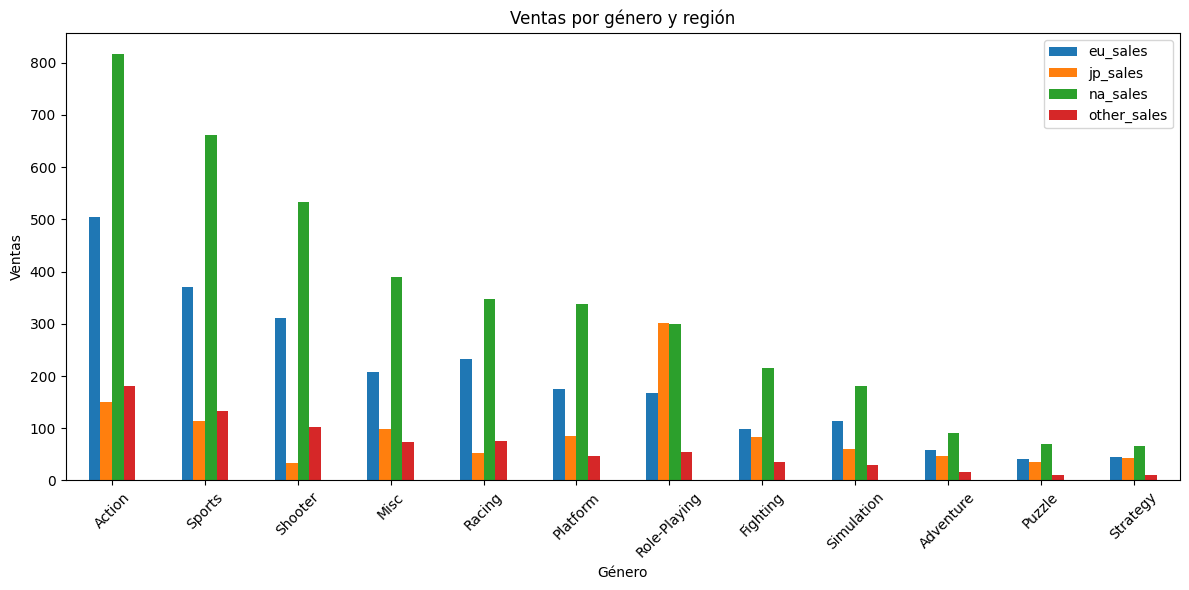

In [167]:
#5
pivot.plot(kind="bar", figsize=(12,6))

plt.title("Ventas por género y región")
plt.xlabel("Género")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [168]:
# Generos con mas ventas por region
generos=ventas_genero_region[["genre","region_top","na_sales","jp_sales","eu_sales","other_sales"]].sort_values(by="na_sales",ascending=False)
generos

,genre,region_top,na_sales,jp_sales,eu_sales,other_sales
0,Action,na_sales,816.36,149.75,503.77,181.26
10,Sports,na_sales,662.12,114.03,370.90,133.24
8,Shooter,na_sales,533.99,33.25,311.69,102.53
3,Misc,na_sales,390.15,98.51,208.25,72.75
6,Racing,na_sales,348.33,51.91,232.57,75.01
4,Platform,na_sales,337.97,85.71,175.33,46.64
7,Role-Playing,jp_sales,300.19,301.15,166.57,54.57
2,Fighting,na_sales,214.54,83.80,98.12,36.00
9,Simulation,na_sales,179.98,60.11,113.33,30.55
1,Adventure,na_sales,90.07,46.19,59.18,15.77


## Lista de generos mas vendidos
Se observa que la region que mas predonina en ventas es en america del norte en casi todos los generos a ecepcion de roll play que so fe sale japon.

In [169]:
lista=list(generos["genre"].unique())
lista

['Action',
 'Sports',
 'Shooter',
 'Misc',
 'Racing',
 'Platform',
 'Role-Playing',
 'Fighting',
 'Simulation',
 'Adventure',
 'Puzzle',
 'Strategy']

# Prueba de Hipotesis
- Las clasificaciones de ESRB (rating) afectan a las ventas en regiones individuales.
- Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
- Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.


In [170]:
# Acectacion de ESRB de la columna rating afecta
#1 Resumen por categoría
cols_regionales = ["na_sales", "eu_sales", "jp_sales", "other_sales"]

resumen_rating = (
    df_games.groupby("rating")[cols_regionales]
    .agg(["count", "mean", "median", "std", "sum"])
)

resumen_rating

na_sales                                     eu_sales                   \
          count      mean median       std      sum    count      mean median   
rating                                                                          
AO            1  1.260000  1.260       NaN     1.26        1  0.610000   0.61   
E          7022  0.285457  0.090  0.979932  2004.48     7022  0.147650   0.02   
E10+       1394  0.247855  0.120  0.436716   345.51     1394  0.131528   0.03   
EC            8  0.191250  0.155  0.142371     1.53        8  0.013750   0.00   
K-A           3  0.853333  0.260  1.259577     2.56        3  0.090000   0.10   
M          2501  0.340328  0.070  0.869172   851.16     2501  0.216429   0.04   
RP            1  0.000000  0.000       NaN     0.00        1  0.030000   0.03   
T          5531  0.206836  0.050  0.615194  1144.01     5531  0.116196   0.02   

                          jp_sales                                     \
             std      sum    count      mean median       std     sum   
rating                                                                  
AO           NaN     0.61        1  0.000000    0.0       NaN    0.00   
E       0.617133  1036.80     7022  0.086136    0.0  0.333819  604.85   
E10+    0.269172   183.35     1394  0.028838    0.0  0.167013   40.20   
EC      0.031595     0.11        8  0.000000    0.0  0.000000    0.00   
K-A     0.075498     0.27        3  0.486667    0.0  0.842931    1.46   
M       0.553009   541.29     2501  0.038105    0.0  0.107348   95.30   
RP           NaN     0.03        1  0.000000    0.0       NaN    0.00   
T       0.348190   642.68     5531  0.099291    0.0  0.363123  549.18   

       other_sales                                     
             count      mean median       std     sum  
rating                                                 
AO               1  0.090000  0.090       NaN    0.09  
E             7022  0.043217  0.010  0.200408  303.47  
E10+          1394  0.051600  0.020  0.106083   71.93  
EC               8  0.013750  0.015  0.013025    0.11  
K-A              3  0.010000  0.000  0.017321    0.03  
M             2501  0.077177  0.010  0.295196  193.02  
RP               1  0.010000  0.010       NaN    0.01  
T             5531  0.039096  0.010  0.107362  216.24

<Figure size 1000x600 with 0 Axes>

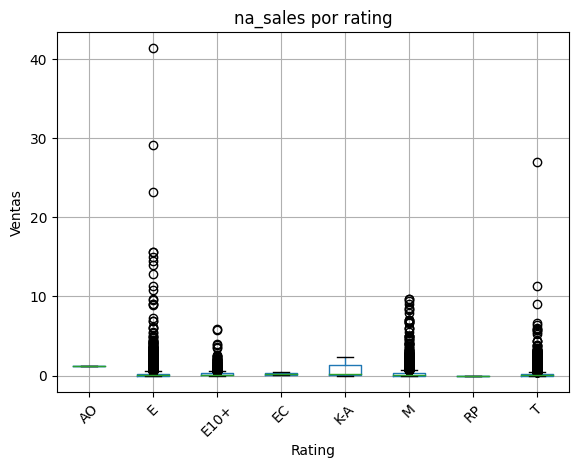

<Figure size 1000x600 with 0 Axes>

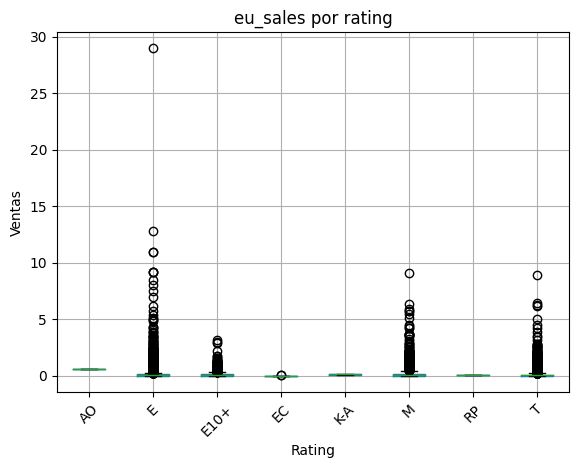

<Figure size 1000x600 with 0 Axes>

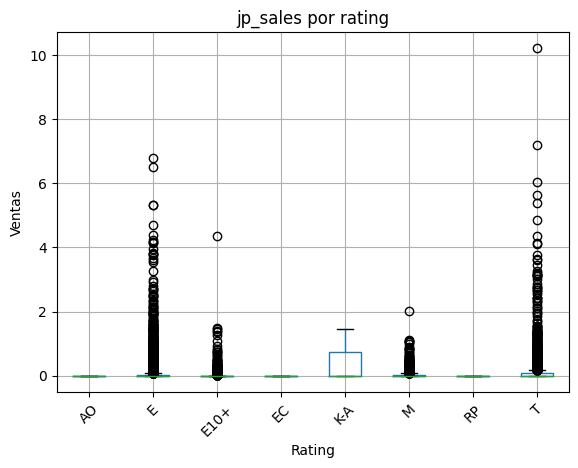

<Figure size 1000x600 with 0 Axes>

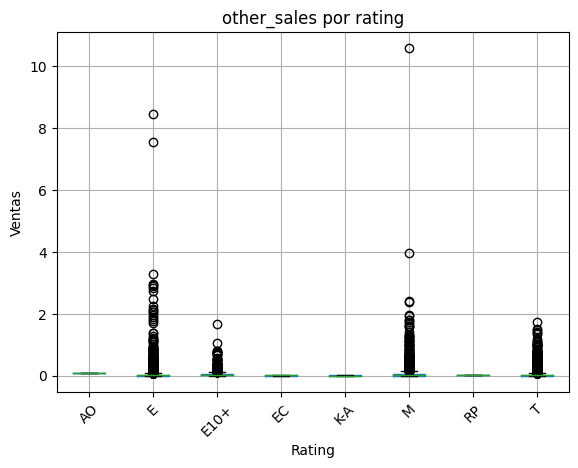

In [171]:
#2  Boxplot por región
import matplotlib.pyplot as plt

for col in cols_regionales:
    plt.figure(figsize=(10,6))
    df_games.boxplot(column=col, by="rating")
    plt.title(f"{col} por rating")
    plt.suptitle("")
    plt.xlabel("Rating")
    plt.ylabel("Ventas")
    plt.xticks(rotation=45)
    plt.show()

In [172]:
#3 ANOVA para cada región
from scipy.stats import f_oneway

for col in cols_regionales:
    grupos = [
        grupo[col].dropna().values
        for _, grupo in df_games.dropna(subset=["rating", col]).groupby("rating")
    ]
    
    if len(grupos) > 1:
        stat, p = f_oneway(*grupos)
        print(f"{col}: F={stat:.4f}, p={p:.6f}")

na_sales: F=8.2076, p=0.000000
eu_sales: F=10.0539, p=0.000000
jp_sales: F=16.1799, p=0.000000
other_sales: F=11.2055, p=0.000000


In [173]:
# Tamaño del efecto: eta cuadrada
import pandas as pd

def eta_squared(df, cat_col, num_col):
    data = df[[cat_col, num_col]].dropna().copy()
    
    media_total = data[num_col].mean()
    
    ss_total = ((data[num_col] - media_total) ** 2).sum()
    
    ss_between = (
        data.groupby(cat_col)[num_col]
        .apply(lambda x: len(x) * (x.mean() - media_total) ** 2)
        .sum()
    )
    
    eta2 = ss_between / ss_total
    return eta2

for col in cols_regionales:
    eta2 = eta_squared(df_games, "rating", col)
    print(f"{col}: eta² = {eta2:.4f}")

na_sales: eta² = 0.0035
eu_sales: eta² = 0.0043
jp_sales: eta² = 0.0068
other_sales: eta² = 0.0047


Las ventas regionales cambian según la categoría de rating, y esta ultima solo explica menos del 0.1% de las ventas.  
raring Explica ~1% de la variación en las ventas, El 99% restante depende de otras cosas (plataforma, marketing, año, franquicia, etc.)

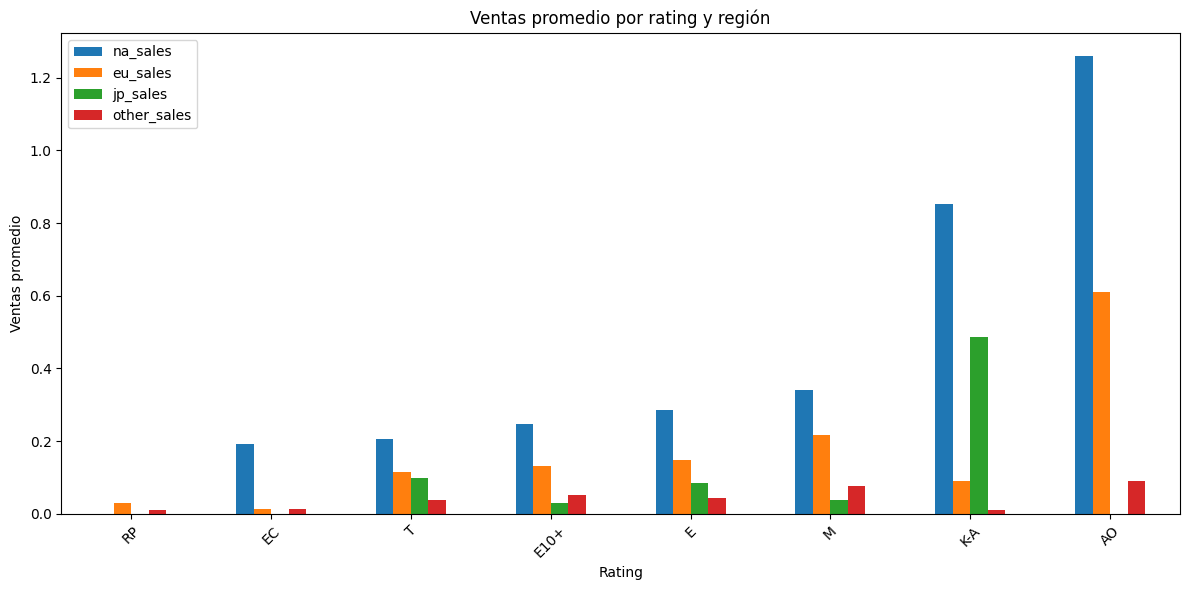

In [174]:
# Grafico
import matplotlib.pyplot as plt

mean_sales_rating = (
    df_games.groupby("rating")[cols_regionales]
    .mean()
).sort_values(by="na_sales")

mean_sales_rating.plot(kind="bar", figsize=(12,6))
plt.title("Ventas promedio por rating y región")
plt.xlabel("Rating")
plt.ylabel("Ventas promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Hipotesis user_score promedio
- [ ] — Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.


1) Xbox One vs PC (user_score)

**Hipótesis.**  
H₀ (nula):
Las medias son iguales.  
μ_XboxOne = μ_PC.  

H₁ (alternativa):
Las medias son diferentes.  
μ_XboxOne ≠ μ_PC

✔ Esto es una prueba bilateral (two-tailed).     
Interpretación.  
Si p < 0.05 → rechazas H₀.  
Sí hay diferencia entre Xbox One y PC.  
Si p ≥ 0.05 → no rechazas H₀.  
No hay evidencia de diferencia.  


In [175]:
from scipy.stats import ttest_ind

df["user_score"] = pd.to_numeric(df["user_score"], errors="coerce")

# Filtrar datoso
xbox = df_games[df_games["platform"] == "XONE"]["user_score"]
pc   = df_games[df_games["platform"] == "PC"]["user_score"]

# Test t
stat, p = ttest_ind(xbox, pc, equal_var=False)

print(f"t={stat:.4f}, p={p:.6f}")

t=-4.4319, p=0.000012


Se rechaza hipotesis nula por lo que si hay diferencias entre juegos de consola y PC.

2) Acción vs Deportes

- [ ] — Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Hipótesis correcta
	•	H₀: μ_Acción = μ_Deportes
	•	H₁: μ_Acción ≠ μ_Deportes.  

    1) p-value
	•	< 0.05 → sí hay diferencia
	•	≥ 0.05 → no hay evidencia


In [176]:
accion = df_games[df_games["genre"] == "Action"]["user_score"].dropna()
deportes = df_games[df_games["genre"] == "Sports"]["user_score"].dropna()

stat, p = ttest_ind(accion, deportes, equal_var=False)

print(f"T={stat:.4f}, p={p:.6f}")

T=0.7078, p=0.479110


Se acepta hipotesis nula.   
Los usuarios califican Acción y Deportes prácticamente igual.   
	•	No hay preferencia clara.  
	•	No hay separación real entre géneros

#  Ciclo de vida de plataformas

In [183]:
vida = df.groupby("platform")["year_of_release"].agg(["min","max"])

In [187]:
vida["años_vida"] = vida["max"] - vida["min"]

In [191]:
vida.sort_values(by="años_vida",ascending=False)

,min,max,años_vida
platform,,,
PC,1985,2016,31
DS,1985,2013,28
GB,1988,2001,13
X360,2005,2016,11
PSP,2004,2015,11
PS2,2000,2011,11
NES,1983,1994,11
DC,1998,2008,10
WII,2006,2016,10


In [190]:
vida.describe()

,min,max,años_vida
count,31.000000,31.000000,31.000000
mean,1997.645161,2005.258065,7.612903
std,9.094131,9.273503,6.998464
min,1980.000000,1989.000000,0.000000
25%,1992.500000,1996.000000,3.000000
50%,1996.000000,2007.000000,6.000000
75%,2004.500000,2016.000000,10.000000
max,2013.000000,2016.000000,31.000000


La vida media de cada plataforma es de 6 años